# Segmentação de Clientes e Análise de Satisfação no E-commerce Brasileiro

Grupo 6 - ESW-008/2026-2 - Engenharia da Informação

Notebook de suporte à monografia da disciplina. Executa, a partir dos dados brutos do Kaggle, a unificação dos dados, a análise exploratória, a segmentação de clientes (RFM: quintis, K-means, K-medoids) e a classificação da satisfação (Regressão Logística, Random Forest, XGBoost), gerando as figuras usadas na monografia.

## 1. Carregamento e Preparação dos Dados

In [1]:
# Todas as bibliotecas usadas no notebook são importadas aqui. Se alguma faltar no seu
# ambiente, o erro aparece já nesta primeira célula — instale com "!pip install <pacote>"
# (kaggle, xgboost e kmedoids costumam ser as que faltam em ambientes novos) e rode de novo.

import os
import time
import warnings

import kmedoids
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import kruskal, mannwhitneyu, skew, wilcoxon
from sklearn.base import clone
from sklearn.cluster import KMeans, kmeans_plusplus
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    auc,
    calinski_harabasz_score,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
    silhouette_score,
)
from sklearn.metrics.pairwise import pairwise_distances
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.utils.class_weight import compute_sample_weight
from xgboost import XGBClassifier

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
warnings.filterwarnings("ignore", category=UserWarning, module="xgboost")

RANDOM_STATE = 42


# --- Detecção de GPU (opcional): se não houver GPU CUDA disponível, cai para CPU sem quebrar ---
def _detect_xgb_device():
    try:
        XGBClassifier(n_estimators=2, device="cuda", tree_method="hist").fit(
            np.random.rand(20, 2), np.random.randint(0, 2, 20)
        )
        return "cuda"
    except Exception:
        return "cpu"


XGB_DEVICE = _detect_xgb_device()
print(f"XGBoost vai rodar em: {XGB_DEVICE}")

XGBoost vai rodar em: cuda


In [2]:
# --- Download e unificação do dataset Olist (Kaggle) ---
# Funciona local ou no Colab, e não depende de nenhum arquivo externo ao notebook.
# Se as pastas de dados não existirem, são criadas automaticamente.

# Caminhos relativos a raiz do projeto (2 niveis acima deste notebook,
# exercises/Trabalho Final/), consistente com as referencias de imagem da monografia
# (../../assets/final/...) e com onde data/ ja existe no repositorio. Um caminho relativo
# so a pasta do notebook (./data, ./assets) causava 2 bugs reais: o notebook nao achava o
# CSV/credenciais do Kaggle ja configurados na raiz (forcando um download desnecessario), e
# os graficos salvos nao apareciam nas imagens que a monografia referencia.
RAW_DIR = "../../data/raw"
PROCESSED_PATH = "../../data/processed/olist_unified.csv"
ASSETS_FINAL = "../../assets/final"
KAGGLE_DATASET = "olistbr/brazilian-ecommerce"

os.makedirs(RAW_DIR, exist_ok=True)
os.makedirs(os.path.dirname(PROCESSED_PATH), exist_ok=True)
os.makedirs(ASSETS_FINAL, exist_ok=True)

_RAW_FILES = [
    "olist_orders_dataset.csv",
    "olist_order_items_dataset.csv",
    "olist_order_payments_dataset.csv",
    "olist_order_reviews_dataset.csv",
    "olist_customers_dataset.csv",
    "olist_products_dataset.csv",
    "olist_sellers_dataset.csv",
    "olist_geolocation_dataset.csv",
    "product_category_name_translation.csv",
]


def _is_colab():
    try:
        import google.colab  # noqa: F401

        return True
    except ImportError:
        return False


def _setup_kaggle_credentials():
    """Garante que ~/.kaggle/kaggle.json existe. No Colab, pede upload; local, orienta o usuário."""
    kaggle_path = os.path.expanduser("~/.kaggle/kaggle.json")
    if os.path.exists(kaggle_path):
        return
    if _is_colab():
        from google.colab import files as _files

        print("Faça upload do kaggle.json (Kaggle -> Settings -> API -> Create New Token):")
        uploaded = _files.upload()
        if "kaggle.json" not in uploaded:
            raise FileNotFoundError("kaggle.json não enviado.")
        os.makedirs(os.path.dirname(kaggle_path), exist_ok=True)
        with open(kaggle_path, "wb") as f:
            f.write(uploaded["kaggle.json"])
        os.chmod(kaggle_path, 0o600)
    else:
        raise FileNotFoundError(
            "kaggle.json não encontrado em ~/.kaggle/kaggle.json. "
            "Gere em https://www.kaggle.com/settings -> API -> Create New Token, "
            "salve nesse caminho e rode esta célula de novo."
        )


def download_dataset(raw_dir=RAW_DIR):
    if all(os.path.exists(os.path.join(raw_dir, fname)) for fname in _RAW_FILES):
        print("Arquivos brutos já presentes, download ignorado.")
        return
    os.makedirs(raw_dir, exist_ok=True)
    _setup_kaggle_credentials()
    import kaggle

    kaggle.api.authenticate()
    kaggle.api.dataset_download_files(KAGGLE_DATASET, path=raw_dir, unzip=True, quiet=False)
    print(f"Dataset baixado em: {raw_dir}")


def unify_datasets(raw_dir=RAW_DIR, output_path=PROCESSED_PATH):
    if os.path.exists(output_path):
        print(f"Dataset unificado ja existe em: {output_path}, carregando direto.")
        return pd.read_csv(output_path)

    download_dataset(raw_dir)

    orders = pd.read_csv(f"{raw_dir}/olist_orders_dataset.csv")
    order_items = pd.read_csv(f"{raw_dir}/olist_order_items_dataset.csv")
    order_payments = pd.read_csv(f"{raw_dir}/olist_order_payments_dataset.csv")
    order_reviews = pd.read_csv(f"{raw_dir}/olist_order_reviews_dataset.csv")
    customers = pd.read_csv(f"{raw_dir}/olist_customers_dataset.csv")
    products = pd.read_csv(f"{raw_dir}/olist_products_dataset.csv")
    sellers = pd.read_csv(f"{raw_dir}/olist_sellers_dataset.csv")
    geolocation = pd.read_csv(f"{raw_dir}/olist_geolocation_dataset.csv")
    category_translation = pd.read_csv(f"{raw_dir}/product_category_name_translation.csv")

    # geolocation: múltiplas coordenadas por CEP -> média
    geo = (
        geolocation.groupby("geolocation_zip_code_prefix")
        .agg(
            geolocation_lat=("geolocation_lat", "mean"),
            geolocation_lng=("geolocation_lng", "mean"),
            geolocation_city=("geolocation_city", "first"),
            geolocation_state=("geolocation_state", "first"),
        )
        .reset_index()
    )

    # payments: valor total = soma; tipo e parcelas = do método com mais parcelas
    payments_agg = (
        order_payments.sort_values("payment_installments", ascending=False)
        .groupby("order_id")
        .agg(
            payment_type=("payment_type", "first"),
            payment_installments=("payment_installments", "first"),
            payment_value=("payment_value", "sum"),
        )
        .reset_index()
    )

    # reviews: múltiplas avaliações por pedido -> a mais recente
    order_reviews["review_creation_date"] = pd.to_datetime(order_reviews["review_creation_date"], format="mixed")
    reviews_agg = order_reviews.sort_values("review_creation_date").drop_duplicates("order_id", keep="last")[
        ["order_id", "review_score", "review_comment_title", "review_comment_message", "review_creation_date"]
    ]

    products = products.merge(category_translation, on="product_category_name", how="left")

    sellers = sellers.merge(
        geo.rename(
            columns={
                "geolocation_zip_code_prefix": "seller_zip_code_prefix",
                "geolocation_lat": "seller_lat",
                "geolocation_lng": "seller_lng",
                "geolocation_city": "seller_city_geo",
                "geolocation_state": "seller_state_geo",
            }
        ),
        on="seller_zip_code_prefix",
        how="left",
    )
    customers = customers.merge(
        geo.rename(
            columns={
                "geolocation_zip_code_prefix": "customer_zip_code_prefix",
                "geolocation_lat": "customer_lat",
                "geolocation_lng": "customer_lng",
                "geolocation_city": "customer_city_geo",
                "geolocation_state": "customer_state_geo",
            }
        ),
        on="customer_zip_code_prefix",
        how="left",
    )

    unified = (
        orders.merge(order_items, on="order_id", how="left")
        .merge(payments_agg, on="order_id", how="left")
        .merge(reviews_agg, on="order_id", how="left")
        .merge(customers, on="customer_id", how="left")
        .merge(products, on="product_id", how="left")
        .merge(sellers, on="seller_id", how="left")
    )

    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    unified.to_csv(output_path, index=False)
    print(f"Dataset unificado salvo em: {output_path}")
    print(f"Dimensões: {unified.shape}")
    return unified

### 1.1 Download, Unificação e Granularidade

O dataset é o **Brazilian E-Commerce Public Dataset by Olist**, público no Kaggle: 9 tabelas relacionais (pedidos, itens, pagamentos, avaliações, clientes, produtos, vendedores, geolocalização e tradução de categorias). A célula abaixo baixa os 9 arquivos brutos via API do Kaggle (se ainda não estiverem localmente) e os unifica em uma única tabela, seguindo o diagrama de relações do dataset.

`olist_unified.csv` tem granularidade por **item de pedido**: pedidos com múltiplos itens aparecem em múltiplas linhas, com `payment_value`, `review_score` e demais campos de pedido repetidos em cada linha. Análises por pedido ou por cliente exigem agregação antes de usar essas colunas (seção 1.2).

**Nota metodológica:** somar `payment_value` diretamente sobre esse dataframe no grain de item, sem deduplicar por `order_id` primeiro, infla o valor monetário em pedidos com mais de 1 item (o pagamento é contado uma vez por item, não uma vez por pedido). A agregação da seção 1.2 evita esse problema.

In [3]:
df = unify_datasets()

date_cols = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "review_creation_date",
]
for col in date_cols:
    df[col] = pd.to_datetime(df[col], format="mixed")

print(f"Linhas (item de pedido): {len(df):,}")
print(f"Pedidos únicos: {df['order_id'].nunique():,}")
print(f"Clientes únicos: {df['customer_unique_id'].nunique():,}")

Dataset unificado ja existe em: ./data/processed/olist_unified.csv, carregando direto.


Linhas (item de pedido): 113,425
Pedidos únicos: 99,441
Clientes únicos: 96,096


### 1.2 Agregação para o Nível de Pedido

A tabela `orders_df` reduz o grain de item para o grain de pedido. Regra de agregação por grupo de coluna:

| Grupo | Colunas | Agregação | Motivo |
|-------|---------|-----------|--------|
| Identificação e status | `order_id`, `customer_id`, `customer_unique_id`, `customer_state`, `order_status`, datas, `payment_type`, `payment_installments`, `payment_value`, `review_score` | primeiro valor (já repetido por item) | Campos de pedido, não de item |
| Financeiro de item | `price`, `freight_value` | soma | Valor total do pedido (produto + frete) |
| Físico de item | `product_weight_g` | soma | Peso total do pacote enviado |
| Físico de item | `product_photos_qty`, `product_description_lenght` | média | Qualidade média do cadastro dos itens do pedido |
| Categórico de item | `product_category_name_english`, `seller_state` | primeiro item (`order_item_id == 1`) | Pedidos multi-item podem ter categorias/vendedores distintos; usa-se o item principal como representativo |

In [4]:
order_level_first = [
    "order_id",
    "customer_id",
    "customer_unique_id",
    "customer_state",
    "order_status",
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date",
    "payment_type",
    "payment_installments",
    "payment_value",
    "review_score",
]

item_first = df[df["order_item_id"] == 1][["order_id", "product_category_name_english", "seller_state", "seller_id"]]

orders_df = (
    df[order_level_first]
    .drop_duplicates("order_id")
    .merge(
        df.groupby("order_id").agg(
            price=("price", "sum"),
            freight_value=("freight_value", "sum"),
            product_weight_g=("product_weight_g", "sum"),
            product_photos_qty=("product_photos_qty", "mean"),
            product_description_lenght=("product_description_lenght", "mean"),
            n_itens=("order_item_id", "max"),
        ),
        on="order_id",
        how="left",
    )
    .merge(item_first, on="order_id", how="left")
)

print(f"Pedidos (grain de pedido): {len(orders_df):,}")
print(
    f"Pedidos com mais de 1 item: {(orders_df['n_itens'] > 1).sum():,} ({(orders_df['n_itens'] > 1).mean() * 100:.1f}%)"
)

# Verificacao: a media sobre itens so adiciona granularidade real onde os itens de um mesmo
# pedido tem product_description_lenght DIFERENTE entre si. Quantifica isso (usado na secao 5.7
# para avaliar se a queda de product_description_lenght na permutation importance e explicada
# por esse efeito, e nao so afirmado).
multi_orders = df[df["order_id"].isin(orders_df.loc[orders_df["n_itens"] > 1, "order_id"])]
var_desc = multi_orders.groupby("order_id")["product_description_lenght"].nunique()
pct_multi_com_variacao = (var_desc > 1).mean() * 100
print(
    f"\nDe {len(var_desc):,} pedidos multi-item, {pct_multi_com_variacao:.1f}% tem "
    f"product_description_lenght DIFERENTE entre itens (media agrega informacao real nesses "
    f"casos, que sao {pct_multi_com_variacao * (orders_df['n_itens'] > 1).mean():.1f}% do total de pedidos)"
)

orders_df.head(3)

Pedidos (grain de pedido): 99,441
Pedidos com mais de 1 item: 9,803 (9.9%)

De 9,803 pedidos multi-item, 28.2% tem product_description_lenght DIFERENTE entre itens (media agrega informacao real nesses casos, que sao 2.8% do total de pedidos)


,order_id,customer_id,customer_unique_id,customer_state,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_type,payment_installments,payment_value,review_score,price,freight_value,product_weight_g,product_photos_qty,product_description_lenght,n_itens,product_category_name_english,seller_state,seller_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,7c396fd4830fd04220f754e42b4e5bff,SP,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,credit_card,1.0,38.71,4.0,29.99,8.72,500.0,4.0,268.0,1.0,housewares,SP,3504c0cb71d7fa48d967e0e4c94d59d9
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,af07308b275d755c9edb36a90c618231,BA,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,boleto,1.0,141.46,4.0,118.70,22.76,400.0,1.0,178.0,1.0,perfumery,SP,289cdb325fb7e7f891c38608bf9e0962
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,3a653a41f6f9fc3d2a113cf8398680e8,GO,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,credit_card,3.0,179.12,5.0,159.90,19.22,420.0,1.0,232.0,1.0,auto,SP,4869f7a5dfa277a7dca6462dcf3b52b2


### 1.3 Variáveis de Logística

`atraso_dias` (dias entre a entrega real e o prazo estimado) e `tempo_entrega` (dias entre a compra e a entrega), calculadas sobre `orders_df` (grain de pedido).

In [5]:
orders_df["tempo_entrega"] = (
    orders_df["order_delivered_customer_date"] - orders_df["order_purchase_timestamp"]
).dt.days

orders_df["atraso_dias"] = (
    orders_df["order_delivered_customer_date"] - orders_df["order_estimated_delivery_date"]
).dt.days

delivered = orders_df[orders_df["order_status"] == "delivered"]
print(f"Pedidos entregues com data válida: {delivered['tempo_entrega'].notna().sum():,}")
print(
    f"Tempo de entrega: média={delivered['tempo_entrega'].mean():.1f}d, mediana={delivered['tempo_entrega'].median():.0f}d"
)
print(
    f"Atraso: média={delivered['atraso_dias'].mean():.1f}d, % pedidos com atraso={((delivered['atraso_dias'] > 0).mean() * 100):.1f}%"
)

Pedidos entregues com data válida: 96,470
Tempo de entrega: média=12.1d, mediana=10d
Atraso: média=-11.9d, % pedidos com atraso=6.8%


### 1.4 RFM por Cliente (Corrigido)

Recência, Frequência e Valor monetário calculados sobre `orders_df` (grain de pedido). `frequencia` conta pedidos únicos e `monetario` soma `payment_value` uma única vez por pedido, corrigindo a inflação identificada na seção 1.1.

In [6]:
REF_DATE = orders_df["order_purchase_timestamp"].max()

rfm = (
    orders_df.groupby("customer_unique_id")
    .agg(
        recencia=("order_purchase_timestamp", lambda x: (REF_DATE - x.max()).days),
        frequencia=("order_id", "nunique"),
        monetario=("payment_value", "sum"),
    )
    .reset_index()
)

print(f"Clientes únicos: {len(rfm):,}")
print(rfm[["recencia", "frequencia", "monetario"]].describe().round(2))
print(f"\nValor monetário total (corrigido): R$ {rfm['monetario'].sum():,.2f}")
print(
    f"Clientes com apenas 1 compra: {(rfm['frequencia'] == 1).sum():,} ({(rfm['frequencia'] == 1).mean() * 100:.1f}%)"
)

Clientes únicos: 96,096
       recencia  frequencia  monetario
count  96096.00    96096.00   96096.00
mean     287.74        1.03     166.59
std      153.41        0.21     231.43
min        0.00        1.00       0.00
25%      163.00        1.00      63.12
50%      268.00        1.00     108.00
75%      397.00        1.00     183.53
max      772.00       17.00   13664.08

Valor monetário total (corrigido): R$ 16,008,872.12
Clientes com apenas 1 compra: 93,099 (96.9%)


### 1.5 Variável-Alvo e Matriz de Features (Classificação)

Alvo de 3 classes definido a partir de `review_score`: insatisfeito (1-2), neutro (3), satisfeito (4-5).

A base de classificação separa 2 motivos de exclusão que a primeira versão deste trabalho misturava: pedidos sem `atraso_dias`/`tempo_entrega`/dado financeiro ou geográfico válido ficam de fora (genuinamente não entregues, seção 1.3); metadado de produto ausente (categoria, fotos, tamanho da descrição) é **imputado**, não descartado, porque grande parte desses pedidos está de fato entregue e avaliada.

Features nos grupos logística, financeiro, produto e geográfico. O grupo comportamental (segmento RFM) é adicionado na seção 3, após a segmentação. `review_comment_title`, `review_comment_message` e qualquer coluna derivada de `review_score` ficam fora: entrariam como vazamento de dados.


In [7]:
FEATURE_COLS = [
    # logística
    "atraso_dias",
    "tempo_entrega",
    "freight_value",
    # financeiro
    "price",
    "payment_value",
    "payment_installments",
    "payment_type",
    # produto
    "product_weight_g",
    "product_photos_qty",
    "product_description_lenght",
    "product_category_name_english",
    # geográfico
    "customer_state",
    "seller_state",
]

# atraso_dias e tempo_entrega so existem para pedidos ENTREGUES (sao NaN para pedidos
# cancelados/em transito). A primeira versao deste trabalho descartava um pedido se QUALQUER
# feature estivesse ausente, inclusive metadado de produto (categoria, fotos, descricao) que
# falta por lacuna de cadastro, nao por falta de entrega. Investigar essa exclusao a fundo
# revelou que 1.369 dos 4.213 pedidos descartados eram, na verdade, ENTREGUES: descartados so
# por metadado de produto ausente. A correcao separa os 2 motivos: dropna so nas colunas que
# genuinamente nao existem sem entrega/pagamento valido; metadado de produto ausente e
# IMPUTADO (categoria vira "outros", fotos/descricao recebem a mediana da base).
LOGISTICS_REQUIRED = ["atraso_dias", "tempo_entrega"]
FINANCIAL_REQUIRED = ["freight_value", "price", "payment_value", "payment_installments", "payment_type"]
PRODUCT_IMPUTABLE = [
    "product_weight_g",
    "product_photos_qty",
    "product_description_lenght",
    "product_category_name_english",
]
GEO_REQUIRED = ["customer_state", "seller_state"]

has_review = orders_df["review_score"].notna()
n_com_review = has_review.sum()

clf_df = orders_df[has_review].dropna(subset=LOGISTICS_REQUIRED + FINANCIAL_REQUIRED + GEO_REQUIRED).copy()
n_recuperados = clf_df[PRODUCT_IMPUTABLE].isna().any(axis=1).sum()

clf_df["product_category_name_english"] = clf_df["product_category_name_english"].fillna("outros")
clf_df["product_photos_qty"] = clf_df["product_photos_qty"].fillna(clf_df["product_photos_qty"].median())
clf_df["product_description_lenght"] = clf_df["product_description_lenght"].fillna(
    clf_df["product_description_lenght"].median()
)

n_excluidos = n_com_review - len(clf_df)
print(f"Pedidos com review: {n_com_review:,}")
print(f"Excluidos (nao entregues de fato, sem atraso/tempo/financeiro/geo valido): {n_excluidos:,}")
print(f"Recuperados por imputacao de metadado de produto (antes descartados por engano): {n_recuperados:,}")


def classe_satisfacao(score):
    if score <= 2:
        return "insatisfeito"
    if score == 3:
        return "neutro"
    return "satisfeito"


clf_df["satisfacao"] = clf_df["review_score"].apply(classe_satisfacao)

print(f"\nPedidos na base de classificacao: {len(clf_df):,}")
print(clf_df["satisfacao"].value_counts(normalize=True).mul(100).round(1))

Pedidos com review: 98,673
Excluidos (nao entregues de fato, sem atraso/tempo/financeiro/geo valido): 2,844
Recuperados por imputacao de metadado de produto (antes descartados por engano): 1,369

Pedidos na base de classificacao: 95,829
satisfacao
satisfeito      78.9
insatisfeito    12.8
neutro           8.3
Name: proportion, dtype: float64


## 2. Caracterização e Preparação dos Dados

Análise exploratória sobre `olist_unified.csv` (113.425 linhas, granularidade por item de pedido) e `orders_df` (grain de pedido). Figuras salvas em `assets/final/`.

### 2.1 Estrutura, Qualidade e Distribuição da Satisfação

In [8]:
nulls = df.isnull().sum()
nulls_pct = (nulls / len(df) * 100).round(1)
print("Colunas com valores ausentes (top 8):")
print(
    pd.DataFrame({"nulos": nulls, "% do total": nulls_pct})[nulls > 0]
    .sort_values("% do total", ascending=False)
    .head(8)
)

print(f"\nLinhas duplicadas: {df.duplicated().sum()}")
print(f"review_score fora do intervalo [1,5]: {((df['review_score'] < 1) | (df['review_score'] > 5)).sum()}")

review_dist = orders_df["review_score"].value_counts(normalize=True).mul(100).round(1).sort_index(ascending=False)
print("\nDistribuição de review_score (%, por pedido):")
print(review_dist)

Colunas com valores ausentes (top 8):
                               nulos  % do total
review_comment_title           99919        88.1
review_comment_message         65501        57.7
order_delivered_customer_date   3229         2.8
product_name_lenght             2378         2.1
product_photos_qty              2378         2.1
product_description_lenght      2378         2.1
product_category_name           2378         2.1
product_category_name_english   2402         2.1



Linhas duplicadas: 0
review_score fora do intervalo [1,5]: 0

Distribuição de review_score (%, por pedido):
review_score
5.0    57.8
4.0    19.3
3.0     8.2
2.0     3.2
1.0    11.5
Name: proportion, dtype: float64


### 2.2 Distribuições e Outliers

O critério adotado: valores extremos são mantidos sem remoção quando têm interpretação semântica válida (produtos caros, fretes de regiões remotas, pedidos multi-item), preferindo estatísticas e algoritmos robustos a outliers (mediana, Spearman, árvores de decisão) em vez de winsorização.

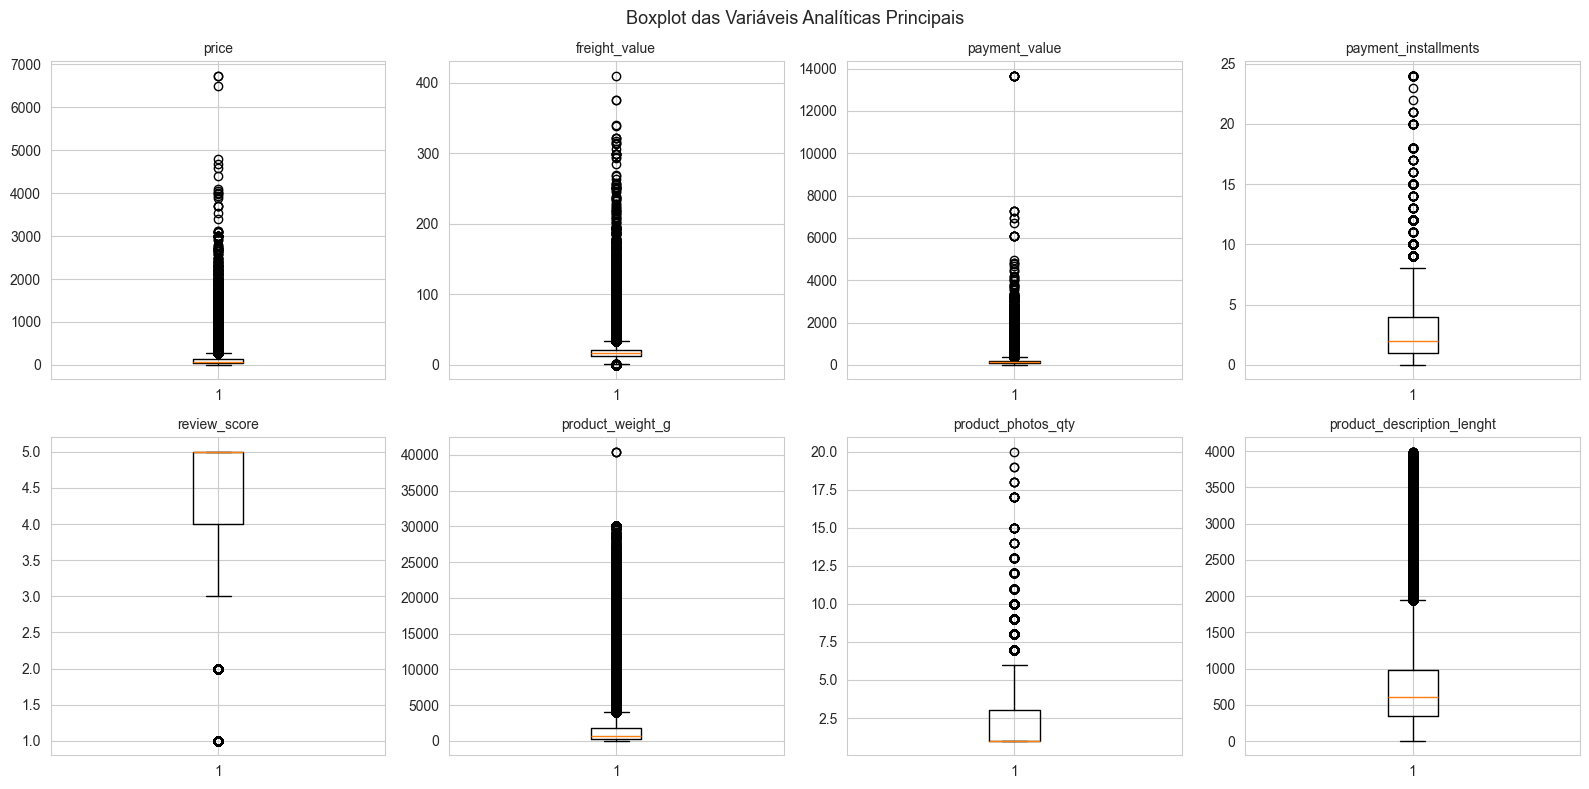

Assimetria (coeficiente de Fisher-Pearson, g1) por variável:
payment_value                 13.76
price                          7.92
freight_value                  5.64
product_weight_g               3.60
product_description_lenght     2.01
product_photos_qty             1.91
payment_installments           1.57
review_score                  -1.25
dtype: float64


In [9]:
box_cols = [
    "price",
    "freight_value",
    "payment_value",
    "payment_installments",
    "review_score",
    "product_weight_g",
    "product_photos_qty",
    "product_description_lenght",
]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for ax, col in zip(axes, box_cols, strict=False):
    ax.boxplot(df[col].dropna(), vert=True)
    ax.set_title(col, fontsize=10)

plt.suptitle("Boxplot das Variáveis Analíticas Principais", fontsize=13)
plt.tight_layout()
plt.savefig(f"{ASSETS_FINAL}/boxplot_variaveis.png", dpi=150, bbox_inches="tight")
plt.show()

assimetria = df[box_cols].apply(lambda s: skew(s.dropna())).round(2)
print("Assimetria (coeficiente de Fisher-Pearson, g1) por variável:")
print(assimetria.sort_values(ascending=False))

### 2.3 Fatores Associados à Satisfação

A correlação de Pearson pressupõe relação linear e é sensível a distribuições assimétricas. Como a maioria das variáveis analíticas tem assimetria alta (seção 2.2), a correlação de Spearman (baseada em postos) é a medida preferencial. A informação mútua complementa a análise ao capturar dependências não-lineares que a correlação (linear ou monotônica) não detecta.

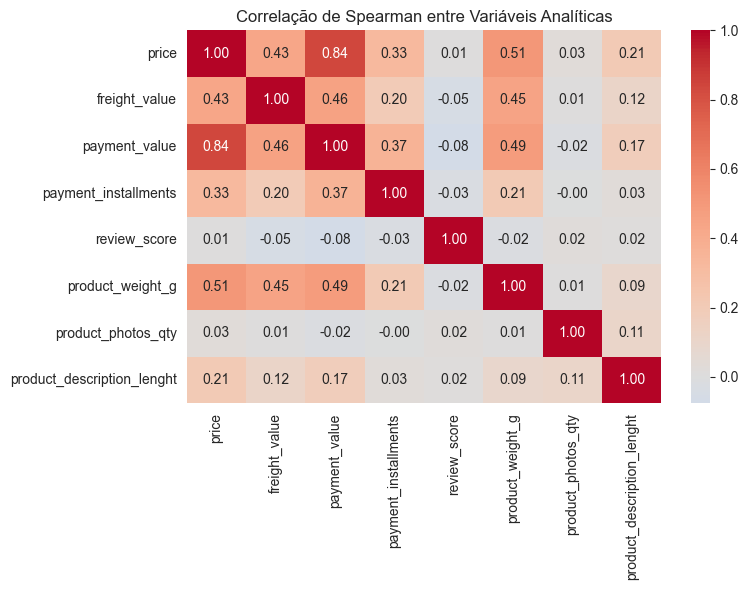

Correlação de Spearman com review_score:
payment_value                -0.076732
freight_value                -0.045646
payment_installments         -0.028993
product_weight_g             -0.017146
price                         0.005990
product_description_lenght    0.015234
product_photos_qty            0.020232
Name: review_score, dtype: float64



Informação mútua com review_score (nível de pedido):
         feature  spearman  informacao_mutua
     atraso_dias    -0.176            0.0669
   tempo_entrega    -0.235            0.0603
   freight_value    -0.088            0.0115
product_weight_g    -0.033            0.0076
           price    -0.029            0.0072


In [10]:
corr_cols = [
    "price",
    "freight_value",
    "payment_value",
    "payment_installments",
    "review_score",
    "product_weight_g",
    "product_photos_qty",
    "product_description_lenght",
]
spearman_corr = df[corr_cols].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(spearman_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
ax.set_title("Correlação de Spearman entre Variáveis Analíticas")
plt.tight_layout()
plt.savefig(f"{ASSETS_FINAL}/heatmap_correlacao.png", dpi=150, bbox_inches="tight")
plt.show()

print("Correlação de Spearman com review_score:")
print(spearman_corr["review_score"].drop("review_score").sort_values())

mi_features = ["atraso_dias", "tempo_entrega", "freight_value", "price", "product_weight_g"]
df_mi = orders_df[[*mi_features, "review_score"]].dropna()
mi_scores = mutual_info_regression(df_mi[mi_features].values, df_mi["review_score"].values, random_state=RANDOM_STATE)
spearman_mi = {f: df_mi[f].corr(df_mi["review_score"], method="spearman") for f in mi_features}

mi_df = pd.DataFrame(
    {
        "feature": mi_features,
        "spearman": [round(spearman_mi[f], 3) for f in mi_features],
        "informacao_mutua": mi_scores.round(4),
    }
).sort_values("informacao_mutua", ascending=False)
print("\nInformação mútua com review_score (nível de pedido):")
print(mi_df.to_string(index=False))

### 2.4 Logística: Atraso e Satisfação

Teste de Kruskal-Wallis (não-paramétrico, adequado à distribuição não-normal de `review_score`) entre as faixas de atraso.

Review medio por faixa de atraso (todas as 6 faixas, soma deve bater com N de df_delay):
                              mean  count
faixa_atraso                             
Muito adiantado (>7d antes)  4.316  70934
Adiantado (1-7d antes)       4.201  17234
No prazo exato               4.034   1280
Atraso leve (1-7d depois)    2.715   3600
Atraso moderado (8-30d)      1.648   2453
Atraso grave (>30d)          2.058    329
soma das contagens: 95,830 | N df_delay: 95,830

Kruskal-Wallis (6 faixas): H=10033.13, p=0.00e+00, epsilon2=0.1047, N=95830


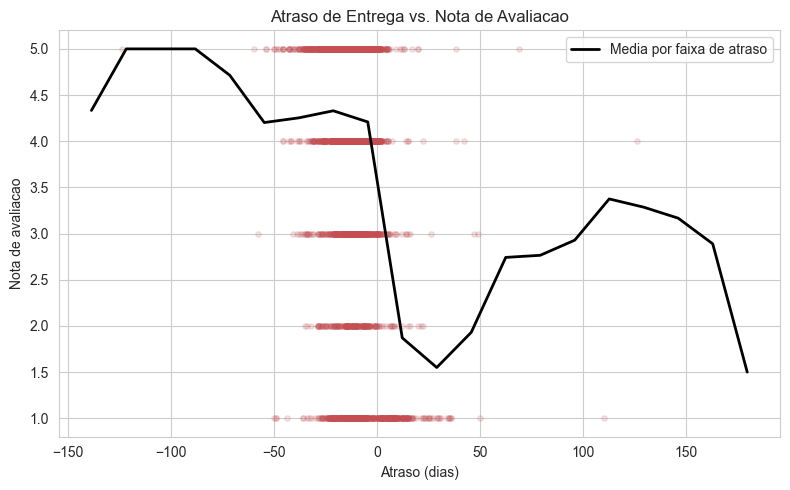

In [11]:
df_delay = orders_df.dropna(subset=["atraso_dias", "review_score"]).copy()


def faixa(d):
    if d < -7:
        return "Muito adiantado (>7d antes)"
    if d < 0:
        return "Adiantado (1-7d antes)"
    if d == 0:
        return "No prazo exato"
    if d <= 7:
        return "Atraso leve (1-7d depois)"
    if d <= 30:
        return "Atraso moderado (8-30d)"
    return "Atraso grave (>30d)"


df_delay["faixa_atraso"] = df_delay["atraso_dias"].apply(faixa)
ordem_faixas = [
    "Muito adiantado (>7d antes)",
    "Adiantado (1-7d antes)",
    "No prazo exato",
    "Atraso leve (1-7d depois)",
    "Atraso moderado (8-30d)",
    "Atraso grave (>30d)",
]
atraso_review = df_delay.groupby("faixa_atraso")["review_score"].agg(["mean", "count"]).reindex(ordem_faixas)
print("Review medio por faixa de atraso (todas as 6 faixas, soma deve bater com N de df_delay):")
print(atraso_review.round(3))
cnt_sum = atraso_review["count"].sum()
print(f"soma das contagens: {cnt_sum:,} | N df_delay: {len(df_delay):,}")

grupos = [g["review_score"].values for _, g in df_delay.groupby("faixa_atraso") if len(g) >= 2]
H, p = kruskal(*grupos)
N, k_faixas = len(df_delay), df_delay["faixa_atraso"].nunique()
eps2 = (H - k_faixas + 1) / (N - k_faixas)
print(f"\nKruskal-Wallis (6 faixas): H={H:.2f}, p={p:.2e}, epsilon2={eps2:.4f}, N={N}")

fig, ax = plt.subplots(figsize=(8, 5))
amostra = df_delay.sample(min(5000, len(df_delay)), random_state=RANDOM_STATE)
ax.scatter(amostra["atraso_dias"], amostra["review_score"], alpha=0.15, s=15, color="#C44E52")

bins = pd.cut(df_delay["atraso_dias"], bins=20)
tendencia = df_delay.groupby(bins, observed=True)["review_score"].mean()
pontos_medios = [interval.mid for interval in tendencia.index]
ax.plot(pontos_medios, tendencia.values, color="black", linewidth=2, label="Media por faixa de atraso")

ax.set_xlabel("Atraso (dias)")
ax.set_ylabel("Nota de avaliacao")
ax.set_title("Atraso de Entrega vs. Nota de Avaliacao")
ax.legend()
plt.tight_layout()
plt.savefig(f"{ASSETS_FINAL}/atraso_review_dispersao.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.5 Dimensão Geográfica

% de clientes em SP: 42.0%
% de PEDIDOS com vendedor em SP: 70.4%
% de VENDEDORES UNICOS sediados em SP: 59.7% (de 3,095 vendedores)

Estados com pelo menos 30 pedidos entregues (de 96,478 pedidos, 27 de 27 estados):

Maior frete medio:
                frete_medio  tempo_medio  review_medio    n
customer_state                                             
PB                    48.84        19.95          4.08  517
RR                    48.34        28.98          3.90   41
RO                    46.43        18.91          4.17  243
AC                    45.55        20.64          4.09   80
PI                    42.98        18.99          3.99  476

Maior tempo medio de entrega:
                frete_medio  tempo_medio  review_medio    n
customer_state                                             
RR                    48.34        28.98          3.90   41
AP                    41.30        26.73          4.24   67
AM                    37.45        25.99          4.24  145
AL          

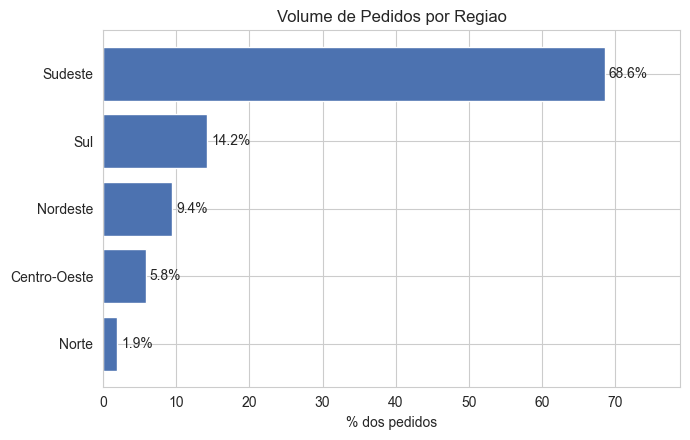

In [12]:
# pct_pedidos_vendedor_sp mede a fracao de PEDIDOS atendidos por vendedor em SP (grao de
# pedido); e diferente de pct_vendedores_unicos_sp, a fracao de VENDEDORES distintos sediados
# em SP (grao de vendedor). As duas respondem perguntas diferentes e nao devem ser confundidas.
pct_pedidos_vendedor_sp = (orders_df["seller_state"] == "SP").mean() * 100
pct_clientes_sp = (orders_df["customer_state"] == "SP").mean() * 100

sellers_unique = df.drop_duplicates("seller_id")[["seller_id", "seller_state"]]
pct_vendedores_unicos_sp = (sellers_unique["seller_state"] == "SP").mean() * 100

print(f"% de clientes em SP: {pct_clientes_sp:.1f}%")
print(f"% de PEDIDOS com vendedor em SP: {pct_pedidos_vendedor_sp:.1f}%")
n_sellers_unicos = sellers_unique["seller_id"].nunique()
print(f"% de VENDEDORES UNICOS sediados em SP: {pct_vendedores_unicos_sp:.1f}% (de {n_sellers_unicos:,} vendedores)")

estado_stats = (
    orders_df[orders_df["order_status"] == "delivered"]
    .groupby("customer_state")
    .agg(
        frete_medio=("freight_value", "mean"),
        tempo_medio=("tempo_entrega", "mean"),
        review_medio=("review_score", "mean"),
        n=("order_id", "nunique"),
    )
    .round(2)
)
n_total_estados = estado_stats["n"].sum()
n_estados_30 = (estado_stats["n"] >= 30).sum()
print(
    f"\nEstados com pelo menos 30 pedidos entregues (de {n_total_estados:,.0f} pedidos, {n_estados_30} de {len(estado_stats)} estados):"
)
estado_stats_30 = estado_stats.query("n >= 30")
print("\nMaior frete medio:")
print(estado_stats_30.sort_values("frete_medio", ascending=False).head(5))
print("\nMaior tempo medio de entrega:")
print(estado_stats_30.sort_values("tempo_medio", ascending=False).head(5))
print("\nMenor review medio:")
print(estado_stats_30.sort_values("review_medio").head(5))

# Concentracao de vendedores: quantos % dos vendedores respondem por 50% da receita?
seller_stats = (
    orders_df[orders_df["order_status"] == "delivered"]
    .groupby("seller_id")
    .agg(receita=("price", "sum"), n_pedidos=("order_id", "nunique"), review_medio=("review_score", "mean"))
    .sort_values("receita", ascending=False)
)
seller_stats["receita_acum_pct"] = seller_stats["receita"].cumsum() / seller_stats["receita"].sum() * 100
n_sellers_50 = int((seller_stats["receita_acum_pct"] <= 50).sum() + 1)
pct_sellers_50 = n_sellers_50 / len(seller_stats) * 100
corr_vol_review = seller_stats["n_pedidos"].corr(seller_stats["review_medio"], method="spearman")
print(f"\n{n_sellers_50} de {len(seller_stats):,} vendedores ({pct_sellers_50:.1f}%) concentram 50% da receita")
print(f"Correlacao (Spearman) entre volume de pedidos do vendedor e review medio: {corr_vol_review:.3f}")

# Pedidos cancelados
canc = orders_df[orders_df["order_status"] == "canceled"]
canc_com_review = canc.dropna(subset=["review_score"])
print(f"\nPedidos cancelados: {len(canc):,} ({len(canc) / len(orders_df) * 100:.2f}% do total)")
review_canc_medio = canc_com_review["review_score"].mean()
print(f"Review medio dos cancelados com avaliacao registrada: {review_canc_medio:.2f} (n={len(canc_com_review):,})")

REGIAO_POR_ESTADO = {
    "AC": "Norte",
    "AP": "Norte",
    "AM": "Norte",
    "PA": "Norte",
    "RO": "Norte",
    "RR": "Norte",
    "TO": "Norte",
    "AL": "Nordeste",
    "BA": "Nordeste",
    "CE": "Nordeste",
    "MA": "Nordeste",
    "PB": "Nordeste",
    "PE": "Nordeste",
    "PI": "Nordeste",
    "RN": "Nordeste",
    "SE": "Nordeste",
    "DF": "Centro-Oeste",
    "GO": "Centro-Oeste",
    "MT": "Centro-Oeste",
    "MS": "Centro-Oeste",
    "ES": "Sudeste",
    "MG": "Sudeste",
    "RJ": "Sudeste",
    "SP": "Sudeste",
    "PR": "Sul",
    "RS": "Sul",
    "SC": "Sul",
}
orders_df["regiao"] = orders_df["customer_state"].map(REGIAO_POR_ESTADO)
region_counts = orders_df["regiao"].value_counts(normalize=True).mul(100).round(1).sort_values(ascending=True)

# Barras, nao pizza: posicao/comprimento sao mais precisos para comparacao do que angulo/area
# (Munzner, 2014), usado de forma consistente com a secao 5.
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.barh(region_counts.index, region_counts.values, color="#4C72B0")
ax.bar_label(bars, fmt="%.1f%%", padding=3)
ax.set_xlabel("% dos pedidos")
ax.set_title("Volume de Pedidos por Regiao")
ax.set_xlim(0, region_counts.max() * 1.15)
plt.tight_layout()
plt.savefig(f"{ASSETS_FINAL}/volume_regiao.png", dpi=150, bbox_inches="tight")
plt.show()

Participacao (%) de cada categoria no volume de pedidos, por regiao:
product_category_name_english  bed_bath_table  computers_accessories  \
regiao                                                                 
Centro-Oeste                             15.1                   11.0   
Nordeste                                 10.0                   12.6   
Norte                                     7.3                   15.2   
Sudeste                                  18.8                   12.1   
Sul                                      15.7                   12.9   

product_category_name_english  furniture_decor  health_beauty  housewares  \
regiao                                                                      
Centro-Oeste                               9.9           18.3         9.4   
Nordeste                                   9.7           21.1         6.5   
Norte                                      9.5           19.3         6.0   
Sudeste                                  

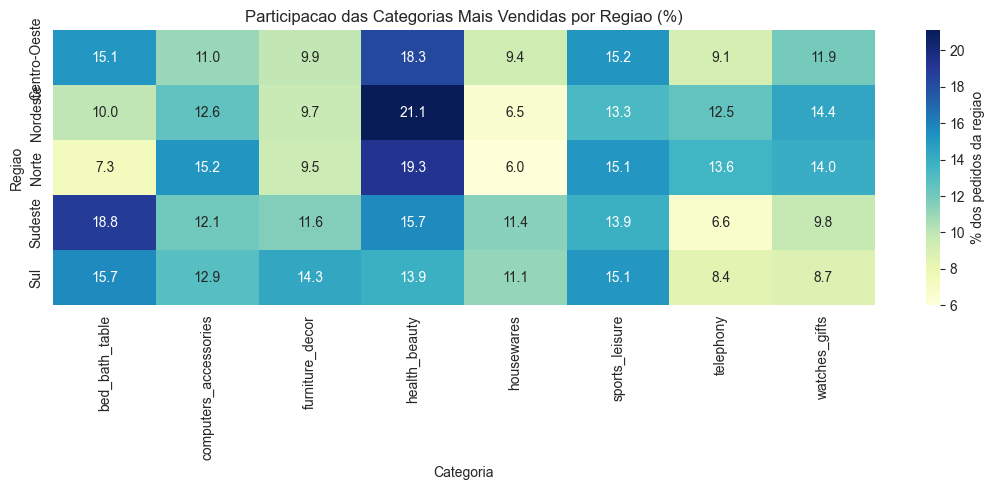

In [13]:
TOP_N_CATEGORIAS = 8
top_categorias = orders_df["product_category_name_english"].value_counts().head(TOP_N_CATEGORIAS).index

cat_regiao = (
    orders_df[orders_df["product_category_name_english"].isin(top_categorias)]
    .groupby(["regiao", "product_category_name_english"], observed=True)
    .size()
    .unstack(fill_value=0)
)
cat_regiao_pct = cat_regiao.div(cat_regiao.sum(axis=1), axis=0).mul(100).round(1)
print("Participacao (%) de cada categoria no volume de pedidos, por regiao:")
print(cat_regiao_pct)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(cat_regiao_pct, annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={"label": "% dos pedidos da regiao"}, ax=ax)
ax.set_title("Participacao das Categorias Mais Vendidas por Regiao (%)")
ax.set_xlabel("Categoria")
ax.set_ylabel("Regiao")
plt.tight_layout()
plt.savefig(f"{ASSETS_FINAL}/volume_categoria_regiao.png", dpi=150, bbox_inches="tight")
plt.show()

### 2.6 Catálogo: Categorias e Receita

17 de 71 categorias concentram 80% da receita


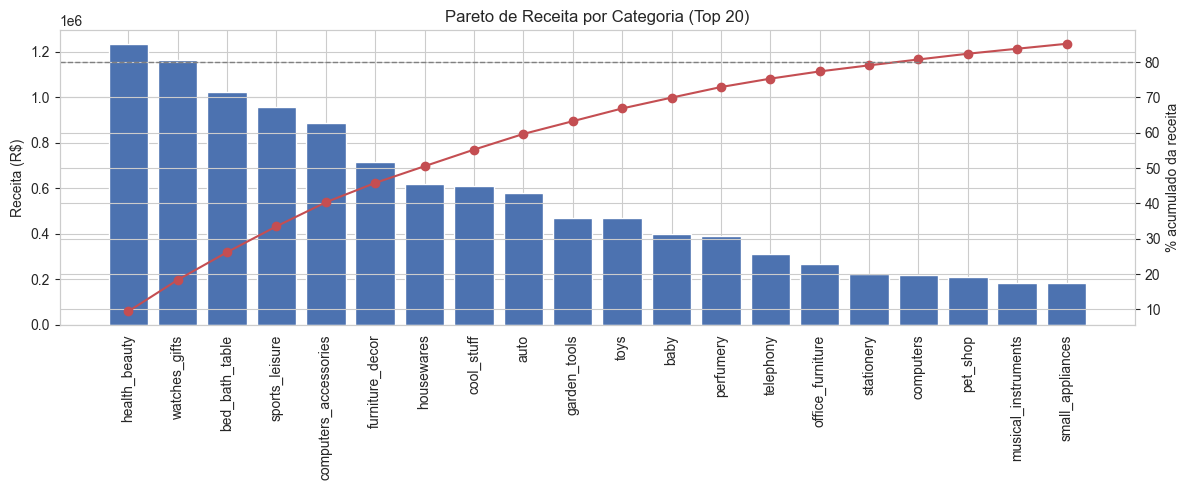

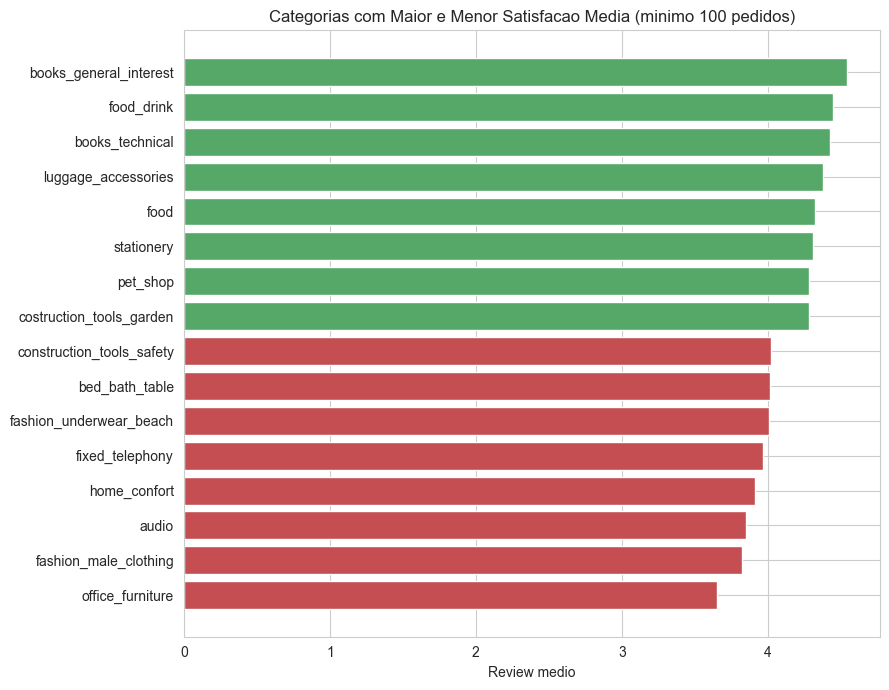


Maior satisfacao:
                               pedidos  review_medio
product_category_name_english                       
books_general_interest             493      4.539877
food_drink                         218      4.444954
books_technical                    255      4.425197

Menor satisfacao:
                               pedidos  review_medio
product_category_name_english                       
audio                              344      3.847507
fashion_male_clothing              106      3.819048
office_furniture                  1246      3.650485

As 2 categorias de maior volume (para H3):
                               pedidos  review_medio
product_category_name_english                       
bed_bath_table                    9167      4.010582
health_beauty                     8608      4.235342

Kruskal-Wallis entre as 10 categorias de maior volume: H=283.73, p=7.32e-56, epsilon2=0.0046, N=60381


In [14]:
cat_stats = (
    orders_df[orders_df["order_status"] == "delivered"]
    .groupby("product_category_name_english")
    .agg(pedidos=("order_id", "nunique"), receita=("price", "sum"), review_medio=("review_score", "mean"))
    .dropna()
    .sort_values("receita", ascending=False)
)
cat_stats["receita_acum_pct"] = cat_stats["receita"].cumsum() / cat_stats["receita"].sum() * 100
n_categorias_80 = int((cat_stats["receita_acum_pct"] <= 80).sum() + 1)
print(f"{n_categorias_80} de {len(cat_stats)} categorias concentram 80% da receita")

top20 = cat_stats.head(20)
fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.bar(top20.index, top20["receita"], color="#4C72B0")
ax1.set_ylabel("Receita (R$)")
ax1.tick_params(axis="x", rotation=90)
ax2 = ax1.twinx()
ax2.plot(top20.index, top20["receita_acum_pct"], color="#C44E52", marker="o")
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)
ax2.set_ylabel("% acumulado da receita")
ax1.set_title("Pareto de Receita por Categoria (Top 20)")
plt.tight_layout()
plt.savefig(f"{ASSETS_FINAL}/pareto_categorias.png", dpi=150, bbox_inches="tight")
plt.show()

cat_review = cat_stats[cat_stats["pedidos"] >= 100].sort_values("review_medio", ascending=False)
top_bottom = pd.concat([cat_review.head(8), cat_review.tail(8)])
cores_bar = ["#55A868"] * 8 + ["#C44E52"] * 8

fig, ax = plt.subplots(figsize=(9, 7))
ax.barh(top_bottom.index[::-1], top_bottom["review_medio"][::-1], color=cores_bar[::-1])
ax.set_xlabel("Review medio")
ax.set_title("Categorias com Maior e Menor Satisfacao Media (minimo 100 pedidos)")
plt.tight_layout()
plt.savefig(f"{ASSETS_FINAL}/satisfacao_categoria.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nMaior satisfacao:")
print(cat_review.head(3)[["pedidos", "review_medio"]])
print("\nMenor satisfacao:")
print(cat_review.tail(3)[["pedidos", "review_medio"]])

print("\nAs 2 categorias de maior volume (para H3):")
print(cat_stats.sort_values("pedidos", ascending=False)[["pedidos", "review_medio"]].head(2))

# H3: "maior volume nao implica maior satisfacao" -- teste formal, nao so leitura visual.
# Kruskal-Wallis (nao-parametrico, mesma familia usada para atraso na secao 2.4) comparando a
# distribuicao de review_score entre as 10 categorias de maior volume.
top10_cats = cat_stats.sort_values("pedidos", ascending=False).head(10).index
base_h3 = orders_df[
    (orders_df["order_status"] == "delivered") & (orders_df["product_category_name_english"].isin(top10_cats))
].dropna(subset=["review_score"])
grupos_cat = [g["review_score"].values for _, g in base_h3.groupby("product_category_name_english")]
H_cat, p_cat = kruskal(*grupos_cat)
N_cat, k_cat = len(base_h3), base_h3["product_category_name_english"].nunique()
eps2_cat = (H_cat - k_cat + 1) / (N_cat - k_cat)
print(
    f"\nKruskal-Wallis entre as 10 categorias de maior volume: H={H_cat:.2f}, p={p_cat:.2e}, epsilon2={eps2_cat:.4f}, N={N_cat}"
)

## 3. Segmentação RFM: Quintis, K-means, K-medoids

### 3.1 Metodologia

Três métodos sobre a mesma base RFM (`rfm`, seção 1.4), 96.096 clientes:

| Método | Papel | Referência |
|--------|-------|-----------|
| Quintis | Baseline, sem otimização de coesão/separação | Prática usual de RFM |
| K-means | Centróides, otimiza similaridade interna | SAHAJ (2021) |
| K-medoids | Medoides, mais robusto a outliers, inicialização K-means++ | WU et al. (2022) |

Cada método é avaliado em duas condições: **k livre** (Calinski-Harabasz, intervalo 2 a 10) e **k fixo = 4** (igual ao número de segmentos do baseline de quintis), para isolar o efeito do algoritmo do efeito do número de grupos.

`recencia`, `frequencia` e `monetario` têm assimetria de Fisher-Pearson extrema (g1 de 0,45, 11,86 e 9,47 por cliente). K-means e K-medoids usam distância euclidiana: sem correção, essa assimetria deixa a distância dominada pela cauda de gastadores extremos, não pela estrutura comportamental da maioria. Este trabalho aplica `log1p` antes do `StandardScaler` para K-means e K-medoids (não para os quintis, que usam `qcut`, invariante a transformação monotônica).

**Restrição de hardware no K-medoids:** o algoritmo PAM/FasterPAM exato (pacote `kmedoids`) exige uma matriz de distância completa entre todos os clientes. Para 96.096 clientes isso equivale a ~73 GB de RAM, inviável neste ambiente. A solução adotada é **CLARA** (Clustering LARge Applications, KAUFMAN; ROUSSEEUW, 1990): a mesma extensão de PAM para bases grandes citada na literatura de K-medoids, e não uma aproximação improvisada. CLARA roda o PAM sobre múltiplas amostras pequenas, atribui a base inteira ao melhor conjunto de medoides encontrado (menor custo total sobre os 96.096 clientes) e mantém a avaliação final (Calinski-Harabasz, silhueta, perfis) sobre a população inteira, não apenas a amostra. Uma checagem direta (seção 3.5) mostra que o próprio CLARA não é determinístico bit a bit, mesmo com seed fixa, no mesmo processo.


In [15]:
RFM_COLS = ["recencia", "frequencia", "monetario"]
scaler_quintil = StandardScaler()
X_rfm_quintil = scaler_quintil.fit_transform(rfm[RFM_COLS])  # escala bruta, so para avaliar a silhueta dos quintis

# K-means e K-medoids usam log1p antes de padronizar (secao 3.1): corrige a assimetria
# extrema de monetario/frequencia, que sem isso deixa a distancia euclidiana dominada pela
# cauda de gastadores extremos.
X_rfm_log = np.log1p(rfm[RFM_COLS].values)
scaler_log = StandardScaler()
X_rfm = scaler_log.fit_transform(X_rfm_log)

g1_antes = skew(rfm[RFM_COLS].values, axis=0)
g1_depois = skew(X_rfm_log, axis=0)
print("Assimetria (Fisher-Pearson g1) ANTES do log1p:", dict(zip(RFM_COLS, g1_antes.round(3), strict=False)))
print("Assimetria (Fisher-Pearson g1) DEPOIS do log1p:", dict(zip(RFM_COLS, g1_depois.round(3), strict=False)))
print("frequencia continua assimetrica mesmo apos o log: sua assimetria vem de um valor")
print("degenerado (96,9% da base = 1), nao de uma cauda longa, entao log1p nao resolve.")

K_RANGE = range(2, 11)
K_FIXO = 4
SIL_SAMPLE = 5000

Assimetria (Fisher-Pearson g1) ANTES do log1p: {'recencia': np.float64(0.445), 'frequencia': np.float64(11.862), 'monetario': np.float64(9.467)}
Assimetria (Fisher-Pearson g1) DEPOIS do log1p: {'recencia': np.float64(-0.573), 'frequencia': np.float64(6.397), 'monetario': np.float64(0.532)}
frequencia continua assimetrica mesmo apos o log: sua assimetria vem de um valor
degenerado (96,9% da base = 1), nao de uma cauda longa, entao log1p nao resolve.


### 3.2 Quintis (Baseline)

R decrescente (recência menor = melhor = 5), F e M crescentes, score somado e mapeado para 4 segmentos de negócio.

In [16]:
# Recencia e Valor monetario tem poucos empates (630 e 28.829 valores distintos em 96.096
# clientes) e aceitam qcut padrao. Frequencia e degenerada: 96,9% dos clientes tem exatamente
# 1 compra, entao qcut(frequencia, 5) quebra ("Bin edges must be unique") porque os quantis
# colapsam no mesmo valor. Um qcut(rank(method="first")) contornaria o erro, mas distribuiria
# clientes IDENTICOS (todos com frequencia=1) em escores de 1 a 5 por posicao de linha no
# DataFrame, isto e, por acaso, nao por comportamento. Em vez disso, usamos um escore por
# contagem direta (capado em 5): reflete o valor real de frequencia, sem aleatoriedade.
rfm["R"] = pd.qcut(rfm["recencia"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F"] = rfm["frequencia"].clip(upper=5).astype(int)
rfm["M"] = pd.qcut(rfm["monetario"], 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["RFM_Score"] = rfm["R"] + rfm["F"] + rfm["M"]

print("Distribuicao do escore F (contagem direta, capada em 5):")
print(rfm["F"].value_counts().sort_index())


def segmento_quintil(s):
    if s >= 12:
        return "Champions"
    if s >= 9:
        return "Loyal"
    if s >= 6:
        return "Potential"
    return "At Risk"


rfm["segmento_quintil"] = rfm["RFM_Score"].apply(segmento_quintil)

# Nota: Champions exige RFM_Score >= 12, e o maximo alcancavel com F=1 (96,9% da base) e
# R(5)+F(1)+M(5)=11. Ou seja, e IMPOSSIVEL pertencer a Champions sem ter comprado mais de
# uma vez: o segmento nao "descobre" que clientes engajados avaliam melhor, ele e definido
# de um jeito que so um cliente ja engajado pode integrar (retomado na secao 3.6).

ch_quintil = calinski_harabasz_score(X_rfm_quintil, rfm["segmento_quintil"])
sil_quintil = silhouette_score(
    X_rfm_quintil, rfm["segmento_quintil"], sample_size=SIL_SAMPLE, random_state=RANDOM_STATE
)

print("\nDistribuicao dos segmentos por quintil:")
print(rfm["segmento_quintil"].value_counts())
print(f"\nCalinski-Harabasz: {ch_quintil:.1f}")
print(f"Silhueta (amostra {SIL_SAMPLE:,}): {sil_quintil:.4f}")

Distribuicao do escore F (contagem direta, capada em 5):
F
1    93099
2     2745
3      203
4       30
5       19
Name: count, dtype: int64



Distribuicao dos segmentos por quintil:
segmento_quintil
Potential    48550
Loyal        23563
At Risk      23508
Champions      475
Name: count, dtype: int64

Calinski-Harabasz: 10750.2
Silhueta (amostra 5,000): 0.0969


### 3.3 Ablacao: Quanto o Bug do Escore F Custava

Para não apenas afirmar que a correção da seção anterior melhora a segmentação, reproduzimos aqui, de forma controlada e isolada, o método antigo (`rank(method="first")` antes do `qcut`) só para fins de comparação. **Esse resultado não é usado em nenhuma análise a partir daqui**, existe só para quantificar o efeito do bug.


In [17]:
# Reproducao isolada do metodo antigo (com bug), so para comparacao. NAO usado no resto do
# notebook: rfm["F"]/"RFM_Score"/"segmento_quintil" continuam sendo a versao corrigida.
F_bug = pd.qcut(rfm["frequencia"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
RFM_Score_bug = rfm["R"] + F_bug + rfm["M"]
segmento_quintil_bug = RFM_Score_bug.apply(segmento_quintil)

ch_bug = calinski_harabasz_score(X_rfm, segmento_quintil_bug)
sil_bug = silhouette_score(X_rfm, segmento_quintil_bug, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE)

ablacao = pd.DataFrame(
    [
        {"versao": "F com bug (rank posicional)", "calinski_harabasz": ch_bug, "silhouette": sil_bug},
        {"versao": "F corrigido (contagem direta)", "calinski_harabasz": ch_quintil, "silhouette": sil_quintil},
    ]
).round(4)
print(ablacao.to_string(index=False))
print(f"\nGanho de silhueta ao corrigir: {sil_quintil - sil_bug:+.4f}")
print(f"Ganho de Calinski-Harabasz: {(ch_quintil / ch_bug - 1) * 100:+.1f}%")

                       versao  calinski_harabasz  silhouette
  F com bug (rank posicional)          8111.7217     -0.0358
F corrigido (contagem direta)         10750.1501      0.0969

Ganho de silhueta ao corrigir: +0.1328
Ganho de Calinski-Harabasz: +32.5%


### 3.4 K-means

Escolha de k pelo índice Calinski-Harabasz no intervalo 2 a 10 (k livre) e ajuste adicional com k fixo = 4.

In [18]:
kmeans_results = []
for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_rfm)
    ch = calinski_harabasz_score(X_rfm, labels)
    sil = silhouette_score(X_rfm, labels, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE)
    kmeans_results.append({"k": k, "calinski_harabasz": ch, "silhouette": sil})

kmeans_results_df = pd.DataFrame(kmeans_results)
k_livre_kmeans = int(kmeans_results_df.loc[kmeans_results_df["calinski_harabasz"].idxmax(), "k"])
print(kmeans_results_df.round(4))
print(f"\nk livre (melhor Calinski-Harabasz): {k_livre_kmeans}")

kmeans_livre = KMeans(n_clusters=k_livre_kmeans, init="k-means++", n_init=10, random_state=RANDOM_STATE)
rfm["segmento_kmeans_livre"] = kmeans_livre.fit_predict(X_rfm)

kmeans_fixo = KMeans(n_clusters=K_FIXO, init="k-means++", n_init=10, random_state=RANDOM_STATE)
rfm["segmento_kmeans_k4"] = kmeans_fixo.fit_predict(X_rfm)

print(f"\nDistribuição k={k_livre_kmeans} (livre):")
print(rfm["segmento_kmeans_livre"].value_counts().sort_index())
print(f"\nDistribuição k={K_FIXO} (fixo):")
print(rfm["segmento_kmeans_k4"].value_counts().sort_index())

    k  calinski_harabasz  silhouette
0   2         45442.8249      0.6991
1   3         57725.3948      0.3742
2   4         73039.0852      0.3767
3   5         70966.9354      0.3527
4   6         70110.4256      0.3413
5   7         70577.5000      0.3558
6   8         70059.6885      0.3440
7   9         69886.0205      0.3426
8  10         69822.6964      0.3385

k livre (melhor Calinski-Harabasz): 4



Distribuição k=4 (livre):
segmento_kmeans_livre
0    25165
1    28918
2    39016
3     2997
Name: count, dtype: int64

Distribuição k=4 (fixo):
segmento_kmeans_k4
0    25165
1    28918
2    39016
3     2997
Name: count, dtype: int64


### 3.5 K-medoids (CLARA + Inicialização K-means++)

Implementação de CLARA: sobre `n_samples` amostras aleatórias de `sample_size` clientes, inicializa os medoides com K-means++ (lógica de WU et al., 2022, para reduzir sensibilidade ao ponto inicial) e refina com FasterPAM. A base inteira é então atribuída ao medoide mais próximo, e o conjunto de medoides com menor custo total (soma das distâncias ao medoide mais próximo) sobre os 96.096 clientes é o escolhido. Ao final, uma checagem direta roda o mesmo procedimento 2 vezes, com a mesma seed, e compara os rótulos de cluster resultantes.


In [19]:
def clara_kmedoids(X, k, n_samples=5, sample_size=3000, random_state=42):
    """CLARA (KAUFMAN; ROUSSEEUW, 1990) com inicializacao K-means++ por amostra (WU et al., 2022)."""
    rng = np.random.default_rng(random_state)
    n = X.shape[0]
    best_cost = np.inf
    best_medoid_points, best_labels = None, None
    for s in range(n_samples):
        idx = rng.choice(n, size=min(sample_size, n), replace=False)
        x_sample = X[idx]
        _, init_idx = kmeans_plusplus(x_sample, k, random_state=random_state + s)
        diss = pairwise_distances(x_sample)
        result = kmedoids.fasterpam(diss, init_idx)
        medoid_points = x_sample[result.medoids]
        d_full = pairwise_distances(X, medoid_points)
        labels_full = d_full.argmin(axis=1)
        cost = d_full.min(axis=1).sum()
        if cost < best_cost:
            best_cost, best_medoid_points, best_labels = cost, medoid_points, labels_full
    return best_labels, best_medoid_points, best_cost


CLARA_N_SAMPLES = 5
CLARA_SAMPLE_SIZE = 3000

kmedoids_results = []
for k in K_RANGE:
    labels, _, cost = clara_kmedoids(X_rfm, k, CLARA_N_SAMPLES, CLARA_SAMPLE_SIZE, RANDOM_STATE)
    ch = calinski_harabasz_score(X_rfm, labels)
    sil = silhouette_score(X_rfm, labels, sample_size=SIL_SAMPLE, random_state=RANDOM_STATE)
    kmedoids_results.append({"k": k, "calinski_harabasz": ch, "silhouette": sil, "custo_total": cost})

kmedoids_results_df = pd.DataFrame(kmedoids_results)
k_livre_kmedoids = int(kmedoids_results_df.loc[kmedoids_results_df["calinski_harabasz"].idxmax(), "k"])
print(kmedoids_results_df.round(4))
print(f"\nk livre (melhor Calinski-Harabasz): {k_livre_kmedoids}")

labels_livre, _, _ = clara_kmedoids(X_rfm, k_livre_kmedoids, CLARA_N_SAMPLES, CLARA_SAMPLE_SIZE, RANDOM_STATE)
rfm["segmento_kmedoids_livre"] = labels_livre

labels_k4, _, _ = clara_kmedoids(X_rfm, K_FIXO, CLARA_N_SAMPLES, CLARA_SAMPLE_SIZE, RANDOM_STATE)
rfm["segmento_kmedoids_k4"] = labels_k4

print(f"\nDistribuicao k={k_livre_kmedoids} (livre):")
print(rfm["segmento_kmedoids_livre"].value_counts().sort_index())
print(f"\nDistribuicao k={K_FIXO} (fixo):")
print(rfm["segmento_kmedoids_k4"].value_counts().sort_index())

# Checagem direta de determinismo (secao 2.3 ja alertava sobre oscilacao numerica do CLARA):
# roda de novo, mesma seed, mesmo processo, e compara os ROTULOS de cluster (nao so as
# metricas agregadas).
labels_k4_repeat, _, _ = clara_kmedoids(X_rfm, K_FIXO, CLARA_N_SAMPLES, CLARA_SAMPLE_SIZE, RANDOM_STATE)
labels_iguais = (labels_k4 == labels_k4_repeat).all()
print(f"\nDeterminismo (mesma seed, 2a execucao no mesmo processo): labels identicos = {labels_iguais}")
print("Se False, confirma que o paralelismo interno de pairwise_distances/fasterpam nao e")
print("controlado pela seed do NumPy: a conclusao qualitativa e estavel, o valor exato nao.")

    k  calinski_harabasz  silhouette  custo_total
0   2         29020.4823      0.3274  108867.6297
1   3         30707.6056      0.3127   91444.5048
2   4         71889.7537      0.3681   78827.9683
3   5         68107.0469      0.3228   71386.0330
4   6         66205.5496      0.3234   65196.7809
5   7         67866.3805      0.3305   59713.8579
6   8         68883.8030      0.3341   55756.2283
7   9         65892.7458      0.3336   52878.4428
8  10         63367.2458      0.3324   50135.0078

k livre (melhor Calinski-Harabasz): 4



Distribuicao k=4 (livre):
segmento_kmedoids_livre
0    32774
1    26652
2    33673
3     2997
Name: count, dtype: int64

Distribuicao k=4 (fixo):
segmento_kmedoids_k4
0    32774
1     2997
2    33673
3    26652
Name: count, dtype: int64



Determinismo (mesma seed, 2a execucao no mesmo processo): labels identicos = False
Se False, confirma que o paralelismo interno de pairwise_distances/fasterpam nao e
controlado pela seed do NumPy: a conclusao qualitativa e estavel, o valor exato nao.


### 3.6 Comparação dos 3 Métodos e Perfis dos Segmentos

Com a correção de escala da seção 3.1 (log1p antes de padronizar), o critério de seleção de k por Calinski-Harabasz passa a escolher k=4 tanto para K-means quanto para K-medoids: o mesmo k do baseline de quintis, não mais uma divergência a justificar.


In [20]:
comparacao = pd.DataFrame(
    [
        {"metodo": "Quintis", "k": 4, "calinski_harabasz": ch_quintil, "silhouette": sil_quintil},
        {
            "metodo": "K-means (k livre)",
            "k": k_livre_kmeans,
            "calinski_harabasz": kmeans_results_df.loc[
                kmeans_results_df["k"] == k_livre_kmeans, "calinski_harabasz"
            ].iloc[0],
            "silhouette": kmeans_results_df.loc[kmeans_results_df["k"] == k_livre_kmeans, "silhouette"].iloc[0],
        },
        {
            "metodo": "K-means (k=4)",
            "k": K_FIXO,
            "calinski_harabasz": kmeans_results_df.loc[kmeans_results_df["k"] == K_FIXO, "calinski_harabasz"].iloc[0],
            "silhouette": kmeans_results_df.loc[kmeans_results_df["k"] == K_FIXO, "silhouette"].iloc[0],
        },
        {
            "metodo": "K-medoids (k livre)",
            "k": k_livre_kmedoids,
            "calinski_harabasz": kmedoids_results_df.loc[
                kmedoids_results_df["k"] == k_livre_kmedoids, "calinski_harabasz"
            ].iloc[0],
            "silhouette": kmedoids_results_df.loc[kmedoids_results_df["k"] == k_livre_kmedoids, "silhouette"].iloc[0],
        },
        {
            "metodo": "K-medoids (k=4)",
            "k": K_FIXO,
            "calinski_harabasz": kmedoids_results_df.loc[kmedoids_results_df["k"] == K_FIXO, "calinski_harabasz"].iloc[
                0
            ],
            "silhouette": kmedoids_results_df.loc[kmedoids_results_df["k"] == K_FIXO, "silhouette"].iloc[0],
        },
    ]
).round(4)

print(comparacao.to_string(index=False))
print("\nNota: a silhueta usa amostra de 5.000 clientes (mesma amostra/seed nos 3 metodos),")
print("valida para COMPARACAO entre metodos, nao o valor exato sobre a populacao inteira.")
print("Calinski-Harabasz usa a populacao inteira nos 3 casos.")

# Review medio por CLIENTE primeiro, so depois por segmento. Usar review_score direto do
# pedido (order-grain) faria clientes com mais de 1 compra pesarem mais de uma vez na
# comparacao entre segmentos e no teste de hipotese abaixo, violando a independencia das
# observacoes que o teste de Mann-Whitney assume. Agregar por cliente primeiro evita isso.
review_por_cliente = orders_df.dropna(subset=["review_score"]).groupby("customer_unique_id")["review_score"].mean()
rfm_review = rfm.merge(review_por_cliente.rename("review_medio_cliente"), on="customer_unique_id", how="inner")

perfil_cols = ["recencia", "frequencia", "monetario"]
perfil_quintil = rfm.groupby("segmento_quintil")[perfil_cols].mean().round(1)
perfil_quintil["review_medio"] = rfm_review.groupby("segmento_quintil")["review_medio_cliente"].mean().round(3)
perfil_kmeans = rfm.groupby("segmento_kmeans_k4")[perfil_cols].mean().round(1)
perfil_kmeans["review_medio"] = rfm_review.groupby("segmento_kmeans_k4")["review_medio_cliente"].mean().round(3)
perfil_kmedoids = rfm.groupby("segmento_kmedoids_k4")[perfil_cols].mean().round(1)
perfil_kmedoids["review_medio"] = rfm_review.groupby("segmento_kmedoids_k4")["review_medio_cliente"].mean().round(3)

print("\nPerfil por segmento (quintis), com review medio por cliente:")
print(perfil_quintil)
print("\nPerfil por segmento (K-means, k=4), com review medio por cliente:")
print(perfil_kmeans)
print("\nPerfil por segmento (K-medoids, k=4), com review medio por cliente:")
print(perfil_kmedoids)

seg_alto_valor_kmeans = perfil_kmeans["monetario"].idxmax()
margem_pct = (perfil_kmeans["monetario"].max() / perfil_kmeans["monetario"].nlargest(2).iloc[1] - 1) * 100
print(
    f"\nSegmento de alto valor (K-means): {seg_alto_valor_kmeans}, margem sobre o 2o "
    f"colocado em monetario: {margem_pct:.2f}% -- desempate apertado, discutido na monografia."
)


# H1: "clientes de alto valor avaliam pior" -- teste formal (Mann-Whitney, grao de cliente,
# 2 lados) no segmento de MAIOR valor medio de cada metodo. Testado simetricamente para
# quintis (Champions, definido por regra fixa de RFM_Score) e K-means (segmento de maior
# monetario): testar rigorosamente so 1 dos 2 metodos e usar leitura visual no outro seria
# comparar com peso e vara diferentes.
def teste_h1(col_segmento, nome_segmento_alto):
    grupo_alto = rfm_review.loc[rfm_review[col_segmento] == nome_segmento_alto, "review_medio_cliente"]
    grupo_resto = rfm_review.loc[rfm_review[col_segmento] != nome_segmento_alto, "review_medio_cliente"]
    U, p = mannwhitneyu(grupo_alto, grupo_resto, alternative="two-sided")
    n1, n2 = len(grupo_alto), len(grupo_resto)
    # Convencao padrao (KERBY, 2014): r = 2U/(n1*n2) - 1. r<0 => grupo_alto tem POSTOS
    # MENORES (avalia pior, confirma H1); r>0 => avalia melhor (inverte H1). A 1a versao
    # deste trabalho usava 1 - 2U/(n1*n2), o NEGATIVO da convencao padrao, invertendo a
    # leitura do sinal sem que o erro fosse percebido.
    rank_biserial = 2 * U / (n1 * n2) - 1
    return {
        "segmento": nome_segmento_alto,
        "n_alto": n1,
        "n_resto": n2,
        "media_alto": grupo_alto.mean(),
        "media_resto": grupo_resto.mean(),
        "mediana_alto": grupo_alto.median(),
        "mediana_resto": grupo_resto.median(),
        "U": U,
        "p": p,
        "rank_biserial": rank_biserial,
    }


res_kmeans = teste_h1("segmento_kmeans_k4", seg_alto_valor_kmeans)
res_quintil = teste_h1("segmento_quintil", "Champions")

h1_results = pd.DataFrame(
    [
        {"metodo": "K-means (alto valor)", **res_kmeans},
        {"metodo": "Quintis (Champions)", **res_quintil},
    ]
)
print("\nH1, teste simetrico (Mann-Whitney, grao de cliente, bicaudal, sinal padrao KERBY 2014):")
print(h1_results.round(4).to_string(index=False))
print("\nOs 2 rank_biserial sao negativos: em postos, o segmento de alto valor avalia PIOR")
print("nos 2 metodos, confirmando H1 (nao invertendo, como a 1a versao deste trabalho, com")
print("o sinal trocado, concluia para os quintis).")

             metodo  k  calinski_harabasz  silhouette
            Quintis  4         10750.1501      0.0969
  K-means (k livre)  4         73039.0852      0.3767
      K-means (k=4)  4         73039.0852      0.3767
K-medoids (k livre)  4         71889.7537      0.3681
    K-medoids (k=4)  4         71889.7537      0.3681

Nota: a silhueta usa amostra de 5.000 clientes (mesma amostra/seed nos 3 metodos),
valida para COMPARACAO entre metodos, nao o valor exato sobre a populacao inteira.
Calinski-Harabasz usa a populacao inteira nos 3 casos.



Perfil por segmento (quintis), com review medio por cliente:
                  recencia  frequencia  monetario  review_medio
segmento_quintil                                               
At Risk              428.7         1.0       61.6         4.126
Champions            105.8         2.5      487.8         4.152
Loyal                158.1         1.1      289.7         4.063
Potential            284.1         1.0      154.5         4.074

Perfil por segmento (K-means, k=4), com review medio por cliente:
                    recencia  frequencia  monetario  review_medio
segmento_kmeans_k4                                               
0                      114.9         1.0      123.2         4.254
1                      335.2         1.0      320.2         3.938
2                      365.5         1.0       69.3         4.082
3                      268.2         2.1      315.0         4.109

Perfil por segmento (K-medoids, k=4), com review medio por cliente:
                      

### 3.7 Segmentos RFM por Categoria

Distribuição das categorias mais vendidas dentro de cada segmento K-means (k=4), para checar se o comportamento de compra (categoria) difere entre segmentos de valor distinto.


Participacao (%) de cada categoria no volume de pedidos, por segmento K-means (k=4):
product_category_name_english  bed_bath_table  computers_accessories  \
segmento_kmeans_k4                                                     
0                                        16.3                   11.0   
1                                        16.2                   13.7   
2                                        17.3                   12.3   
3                                        22.5                   11.0   

product_category_name_english  furniture_decor  health_beauty  housewares  \
segmento_kmeans_k4                                                          
0                                         10.2           19.9        12.9   
1                                         11.4           14.9         8.0   
2                                         12.3           15.0        11.3   
3                                         15.2           13.6         9.3   

product_category_na

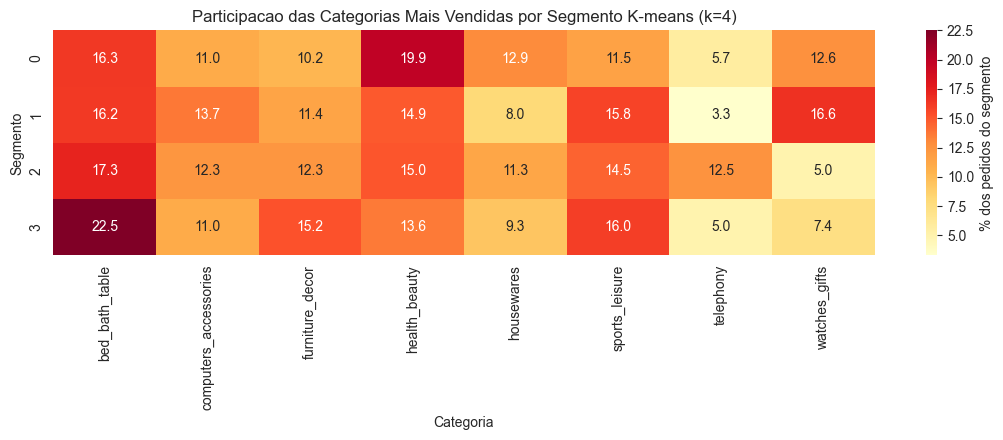

In [21]:
seg_categoria = orders_df.merge(rfm[["customer_unique_id", "segmento_kmeans_k4"]], on="customer_unique_id", how="inner")
top_categorias_seg = seg_categoria["product_category_name_english"].value_counts().head(8).index
seg_cat_tab = (
    seg_categoria[seg_categoria["product_category_name_english"].isin(top_categorias_seg)]
    .groupby(["segmento_kmeans_k4", "product_category_name_english"], observed=True)
    .size()
    .unstack(fill_value=0)
)
seg_cat_pct = seg_cat_tab.div(seg_cat_tab.sum(axis=1), axis=0).mul(100).round(1)
print("Participacao (%) de cada categoria no volume de pedidos, por segmento K-means (k=4):")
print(seg_cat_pct)

fig, ax = plt.subplots(figsize=(11, 4.5))
sns.heatmap(seg_cat_pct, annot=True, fmt=".1f", cmap="YlOrRd", cbar_kws={"label": "% dos pedidos do segmento"}, ax=ax)
ax.set_title("Participacao das Categorias Mais Vendidas por Segmento K-means (k=4)")
ax.set_xlabel("Categoria")
ax.set_ylabel("Segmento")
plt.tight_layout()
plt.savefig(f"{ASSETS_FINAL}/categoria_por_segmento.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Classificação de Satisfação: Regressão Logística, Random Forest, XGBoost

### 4.1 Metodologia

Segmento RFM entra como feature categórica "segmento". O experimento roda **3 vezes**, uma para cada método de segmentação (`segmento_quintil`, `segmento_kmeans_k4`, `segmento_kmedoids_k4`, todos com k=4 para comparabilidade direta) para entender o efeito de cada método na classificação, não só compará-los isoladamente (seção 3).

| Item | Configuração |
|------|--------------|
| Modelos | Regressão Logística (baseline), Random Forest, XGBoost |
| Amostragem | Holdout agrupado por cliente (`GroupShuffleSplit`) 80/20 e 70/30; melhor proporção decidida a priori pela estabilidade da classe insatisfeito, não pela pontuação no teste |
| Validação | k-fold agrupado e estratificado (`StratifiedGroupKFold`), k=5, dentro do treino |
| Desbalanceamento | `class_weight='balanced'` (LogReg, RF); `sample_weight` inverso da frequência (XGBoost) |
| Métricas principais | F1 e PR-AUC one-vs-rest da classe insatisfeito, com IC95% por bootstrap (1.000 reamostragens do teste) |
| Métricas de apoio | F1 macro, precisão/revocação por classe, ROC-AUC, acurácia, matriz de confusão 3x3 |
| Semente | `random_state = 42` |

O holdout é agrupado por `customer_unique_id`, não por pedido: 4,1% dos clientes têm mais de 1 compra, e um split por pedido poderia colocar 2 pedidos do mesmo cliente em treino e teste ao mesmo tempo, uma fonte de vazamento adicional às já discutidas na seção 3. `GroupShuffleSplit` não estratifica por classe diretamente; isso foi verificado abaixo, não assumido.


In [22]:
SEGMENT_METHODS = {
    "quintil": "segmento_quintil",
    "kmeans": "segmento_kmeans_k4",
    "kmedoids": "segmento_kmedoids_k4",
}

clf_base = clf_df.merge(
    rfm[["customer_unique_id", "segmento_quintil", "segmento_kmeans_k4", "segmento_kmedoids_k4"]],
    on="customer_unique_id",
    how="inner",
)

NUMERIC_COLS = [
    "atraso_dias",
    "tempo_entrega",
    "freight_value",
    "price",
    "payment_value",
    "payment_installments",
    "product_weight_g",
    "product_photos_qty",
    "product_description_lenght",
]
BASE_CATEGORICAL_COLS = ["payment_type", "product_category_name_english", "customer_state", "seller_state"]
CLASSES_ORDER = ["insatisfeito", "neutro", "satisfeito"]
SPLIT_RATIOS = [0.2, 0.3]

print(f"Base de classificacao com segmentos: {len(clf_base):,} pedidos")

Base de classificacao com segmentos: 95,829 pedidos


In [23]:
LABEL_ENCODER = LabelEncoder().fit(CLASSES_ORDER)


def build_preprocessor(categorical_cols, scale_numeric):
    numeric_step = StandardScaler() if scale_numeric else "passthrough"
    return ColumnTransformer(
        [
            ("num", numeric_step, NUMERIC_COLS),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols),
        ]
    )


def make_model(model_name):
    if model_name == "logreg":
        return LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    if model_name == "random_forest":
        return RandomForestClassifier(n_estimators=150, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=4)
    return XGBClassifier(
        n_estimators=150, random_state=RANDOM_STATE, eval_metric="mlogloss", device=XGB_DEVICE, tree_method="hist"
    )


def fit_predict(pipe, model_name, x_fit, y_fit, x_eval):
    if model_name == "xgboost":
        sw = compute_sample_weight("balanced", y_fit)
        y_fit_enc = LABEL_ENCODER.transform(y_fit)
        pipe.fit(x_fit, y_fit_enc, clf__sample_weight=sw)
        pred = LABEL_ENCODER.inverse_transform(pipe.predict(x_eval))
        proba, proba_classes = pipe.predict_proba(x_eval), list(LABEL_ENCODER.classes_)
    else:
        pipe.fit(x_fit, y_fit)
        pred = pipe.predict(x_eval)
        proba, proba_classes = pipe.predict_proba(x_eval), list(pipe.named_steps["clf"].classes_)
    col_idx = [proba_classes.index(c) for c in CLASSES_ORDER]
    return pred, proba[:, col_idx]


def cross_validate_f1_macro(categorical_cols, scale, model_name, x_train, y_train, groups_train, n_splits=5):
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    scores = []
    for fold_i, (tr_idx, va_idx) in enumerate(cv.split(x_train, y_train, groups=groups_train), start=1):
        x_tr, x_va = x_train.iloc[tr_idx], x_train.iloc[va_idx]
        y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]
        pipe_cv = Pipeline(
            [("pre", build_preprocessor(categorical_cols, scale)), ("clf", clone(make_model(model_name)))]
        )
        pred, _ = fit_predict(pipe_cv, model_name, x_tr, y_tr, x_va)
        scores.append(f1_score(y_va, pred, average="macro"))
        print(
            f"    [{time.strftime('%H:%M:%S')}] fold {fold_i}/{n_splits} concluido, f1_macro={scores[-1]:.4f}",
            flush=True,
        )
    return np.mean(scores), np.std(scores)


def bootstrap_ci_f1(y_test, pred, target_label, n_boot=1000, seed=RANDOM_STATE):
    """IC95% por bootstrap percentil: reamostra os PARES (y_true, y_pred) do teste, sem
    retreinar nada, e recalcula o F1 a cada reamostragem. Responde diretamente se a diferenca
    nominal de F1 entre metodos de segmentacao (secao 5.1) e maior que o ruido de amostragem."""
    rng = np.random.default_rng(seed)
    y_test_arr, pred_arr = np.asarray(y_test), np.asarray(pred)
    n = len(y_test_arr)
    boot_scores = np.empty(n_boot)
    for b in range(n_boot):
        idx = rng.integers(0, n, n)
        boot_scores[b] = f1_score(
            y_test_arr[idx], pred_arr[idx], labels=[target_label], average="micro", zero_division=0
        )
    return np.percentile(boot_scores, [2.5, 97.5])


def run_experiment(segment_key):
    segment_col_name = SEGMENT_METHODS[segment_key]
    categorical_cols = [*BASE_CATEGORICAL_COLS, "segmento"]
    data = clf_base.rename(columns={segment_col_name: "segmento"})
    x_all, y_all = data[NUMERIC_COLS + categorical_cols], data["satisfacao"]
    groups_all = data["customer_unique_id"]

    rows = []
    for test_size in SPLIT_RATIOS:
        gss = GroupShuffleSplit(n_splits=1, test_size=test_size, random_state=RANDOM_STATE)
        tr_idx, te_idx = next(gss.split(x_all, y_all, groups=groups_all))
        x_train, x_test = x_all.iloc[tr_idx], x_all.iloc[te_idx]
        y_train, y_test = y_all.iloc[tr_idx], y_all.iloc[te_idx]
        groups_train = groups_all.iloc[tr_idx]

        for model_name in ["logreg", "random_forest", "xgboost"]:
            t0 = time.time()
            print(
                f"[{time.strftime('%H:%M:%S')}] INICIO segmentacao={segment_key} test_size={test_size} modelo={model_name}",
                flush=True,
            )
            scale = model_name == "logreg"
            cv_mean, cv_std = cross_validate_f1_macro(
                categorical_cols, scale, model_name, x_train, y_train, groups_train
            )

            pipe = Pipeline([("pre", build_preprocessor(categorical_cols, scale)), ("clf", make_model(model_name))])
            pred, proba_ord = fit_predict(pipe, model_name, x_train, y_train, x_test)

            f1c = f1_score(y_test, pred, labels=CLASSES_ORDER, average=None, zero_division=0)
            precc = precision_score(y_test, pred, labels=CLASSES_ORDER, average=None, zero_division=0)
            recc = recall_score(y_test, pred, labels=CLASSES_ORDER, average=None, zero_division=0)
            prec_curve, rec_curve, _ = precision_recall_curve((y_test == "insatisfeito").astype(int), proba_ord[:, 0])
            ci_lo, ci_hi = bootstrap_ci_f1(y_test.values, pred, "insatisfeito")

            feature_names = pipe.named_steps["pre"].get_feature_names_out()
            seg_mask = np.array(["segmento" in f for f in feature_names])
            if model_name == "logreg":
                # coef_ tem forma (n_classes, n_features) no caso multinomial (3 classes aqui).
                # Somar so a linha 0 (classe "insatisfeito") subestimaria a importancia real do
                # segmento, ignorando o efeito nas classes "neutro" e "satisfeito". Somamos o
                # valor absoluto em todas as classes, comparavel ao que RF/XGBoost fazem (a
                # importancia por impureza tambem agrega o efeito da feature nas 3 classes).
                importancia_segmento = np.abs(pipe.named_steps["clf"].coef_[:, seg_mask]).sum()
            else:
                importancia_segmento = pipe.named_steps["clf"].feature_importances_[seg_mask].sum()

            rows.append(
                {
                    "segmentacao": segment_key,
                    "test_size": test_size,
                    "modelo": model_name,
                    "f1_insatisfeito": f1c[0],
                    "f1_insatisfeito_ci_lo": ci_lo,
                    "f1_insatisfeito_ci_hi": ci_hi,
                    "f1_neutro": f1c[1],
                    "f1_satisfeito": f1c[2],
                    "f1_macro": f1c.mean(),
                    "precision_insatisfeito": precc[0],
                    "recall_insatisfeito": recc[0],
                    "pr_auc_insatisfeito": auc(rec_curve, prec_curve),
                    "roc_auc_ovr": roc_auc_score(y_test, proba_ord, multi_class="ovr", labels=CLASSES_ORDER),
                    "accuracy": accuracy_score(y_test, pred),
                    "cv_f1_macro_mean": cv_mean,
                    "cv_f1_macro_std": cv_std,
                    "importancia_segmento": importancia_segmento,
                    "confusion_matrix": confusion_matrix(y_test, pred, labels=CLASSES_ORDER),
                }
            )
            print(
                f"[{time.strftime('%H:%M:%S')}] FIM segmentacao={segment_key} test_size={test_size} modelo={model_name} "
                f"(levou {time.time() - t0:.1f}s) f1_insatisfeito={f1c[0]:.4f} IC95=[{ci_lo:.4f},{ci_hi:.4f}]",
                flush=True,
            )
    return pd.DataFrame(rows)

### 4.2 Execução dos 3 Experimentos

In [24]:
resultados = pd.concat([run_experiment(key) for key in SEGMENT_METHODS], ignore_index=True)

cols_show = [
    "segmentacao",
    "test_size",
    "modelo",
    "f1_insatisfeito",
    "pr_auc_insatisfeito",
    "f1_macro",
    "roc_auc_ovr",
    "accuracy",
    "cv_f1_macro_mean",
    "cv_f1_macro_std",
    "importancia_segmento",
]
print(resultados[cols_show].round(4).to_string(index=False))

[16:05:26] INICIO segmentacao=quintil test_size=0.2 modelo=logreg


    [16:05:45] fold 1/5 concluido, f1_macro=0.4117


    [16:05:46] fold 2/5 concluido, f1_macro=0.4135


    [16:05:48] fold 3/5 concluido, f1_macro=0.4099


    [16:05:50] fold 4/5 concluido, f1_macro=0.4131


...

    [16:46:27] fold 3/5 concluido, f1_macro=0.4390


    [16:46:29] fold 4/5 concluido, f1_macro=0.4451


    [16:46:31] fold 5/5 concluido, f1_macro=0.4490


[16:47:11] FIM segmentacao=kmedoids test_size=0.3 modelo=xgboost (levou 65.4s) f1_insatisfeito=0.4098 IC95=[0.3971,0.4238]


segmentacao  test_size        modelo  f1_insatisfeito  pr_auc_insatisfeito  f1_macro  roc_auc_ovr  accuracy  cv_f1_macro_mean  cv_f1_macro_std  importancia_segmento
    quintil        0.2        logreg           0.3728               0.3780    0.4150       0.6455    0.5790            0.4121           0.0013                0.7164
    quintil        0.2 random_forest           0.4323               0.4260    0.4533       0.6597    0.7850            0.4496           0.0038                0.0265
    quintil        0.2       xgboost           0.4183               0.4369    0.4476       0.6550    0.6284            0.4439           0.0036                0.0352
    quintil        0.3        logreg           0.3652               0.3721    0.4129       0.6436    0.5783            0.4119           0.0036                0.7232
    quintil        0.3 random_forest           0.4266               0.4199    0.4547       0.6609    0.7878            0.4511           0.0035                0.0290
    quinti

## 5. Visualizações de Resultados

### 5.1 Configuração e Comparação dos Métodos de Segmentação

Figuras salvas em `assets/final/`.

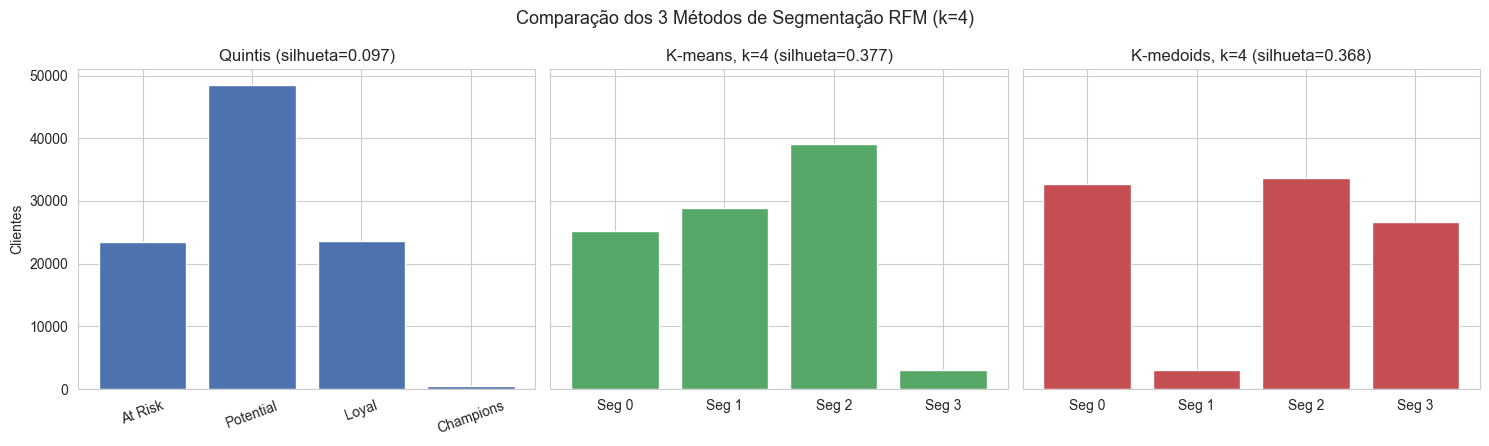

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

order_q = ["At Risk", "Potential", "Loyal", "Champions"]
counts_q = rfm["segmento_quintil"].value_counts().reindex(order_q)
axes[0].bar(counts_q.index, counts_q.values, color="#4C72B0")
axes[0].set_title(f"Quintis (silhueta={sil_quintil:.3f})")
axes[0].tick_params(axis="x", rotation=20)

counts_km = rfm["segmento_kmeans_k4"].value_counts().sort_index()
sil_kmeans_k4 = kmeans_results_df.loc[kmeans_results_df["k"] == K_FIXO, "silhouette"].iloc[0]
axes[1].bar([f"Seg {i}" for i in counts_km.index], counts_km.values, color="#55A868")
axes[1].set_title(f"K-means, k=4 (silhueta={sil_kmeans_k4:.3f})")

counts_kmed = rfm["segmento_kmedoids_k4"].value_counts().sort_index()
sil_kmedoids_k4 = kmedoids_results_df.loc[kmedoids_results_df["k"] == K_FIXO, "silhouette"].iloc[0]
axes[2].bar([f"Seg {i}" for i in counts_kmed.index], counts_kmed.values, color="#C44E52")
axes[2].set_title(f"K-medoids, k=4 (silhueta={sil_kmedoids_k4:.3f})")

axes[0].set_ylabel("Clientes")

plt.suptitle("Comparação dos 3 Métodos de Segmentação RFM (k=4)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{ASSETS_FINAL}/segmentacao_comparacao.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.2 Perfis RFM por Segmento (K-means e K-medoids, k=4)

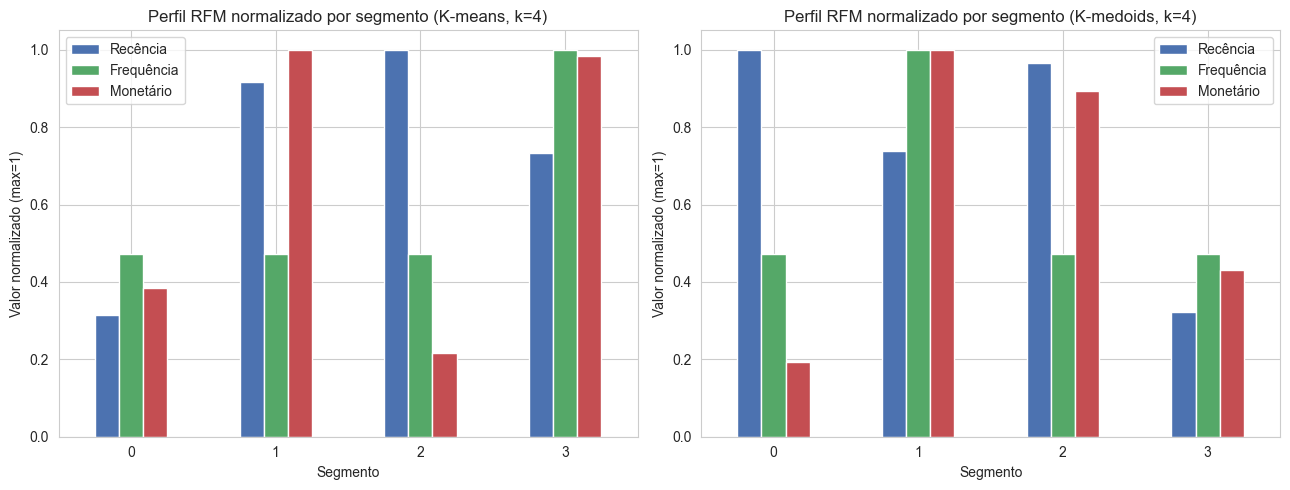

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, metodo in zip(
    axes, ["segmento_kmeans_k4", "segmento_kmedoids_k4"], ["K-means", "K-medoids"], strict=False
):
    perfil = rfm.groupby(col)[perfil_cols].mean()
    perfil_norm = perfil / perfil.max()
    perfil_norm.plot(kind="bar", ax=ax, color=["#4C72B0", "#55A868", "#C44E52"])
    ax.set_title(f"Perfil RFM normalizado por segmento ({metodo}, k=4)")
    ax.set_xlabel("Segmento")
    ax.set_ylabel("Valor normalizado (max=1)")
    ax.tick_params(axis="x", rotation=0)
    ax.legend(["Recência", "Frequência", "Monetário"])

plt.tight_layout()
plt.savefig(f"{ASSETS_FINAL}/perfis_rfm_kmeans_kmedoids.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.3 Decisão da Proporção Treino/Teste

Comparação de F1 e PR-AUC da classe insatisfeito entre 80/20 e 70/30, média sobre os 9 pares segmentação×modelo. A proporção final não é escolhida por essa comparação (ver ressalva de independência abaixo), é decidida a priori pela estabilidade da métrica na classe minoritária.


Media por proporcao de teste:
           f1_insatisfeito  pr_auc_insatisfeito
test_size                                      
0.2                 0.4071               0.4144
0.3                 0.4012               0.4064

Diferenca media de F1 insatisfeito (70/30 menos 80/20): -0.0059
Desvio padrao medio entre folds da validacao cruzada: 0.0036
70/30 supera 80/20 em F1 insatisfeito em 0 de 9 pares segmentacao x modelo.
Teste de Wilcoxon pareado (70/30 vs 80/20, 9 pares): estatistica=0.00, p=0.0039
RESSALVA: os 9 pares NAO sao observacoes independentes, o pressuposto que o Wilcoxon
assume -- eles compartilham o mesmo conjunto de teste dentro de cada proporcao (3
segmentacoes x 3 modelos, todos avaliados sobre a mesma particao). O p-valor acima e
reportado por transparencia, nao como evidencia estatistica valida de diferenca real.

Proporcao escolhida: 70/30 (estabilidade da estimativa na classe minoritaria, nao por vencer no F1 de teste)


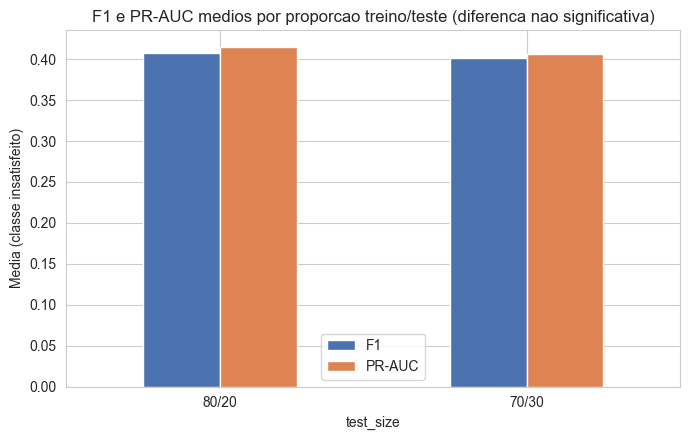

In [27]:
split_medias = resultados.groupby("test_size")[["f1_insatisfeito", "pr_auc_insatisfeito"]].mean()
print("Media por proporcao de teste:")
print(split_medias.round(4))

diff_f1 = resultados.pivot(index=["segmentacao", "modelo"], columns="test_size", values="f1_insatisfeito")
diff_f1_media = (diff_f1[0.3] - diff_f1[0.2]).mean()
cv_std_media = resultados["cv_f1_macro_std"].mean()
vitorias_70_30 = (diff_f1[0.3] > diff_f1[0.2]).sum()
print(f"\nDiferenca media de F1 insatisfeito (70/30 menos 80/20): {diff_f1_media:+.4f}")
print(f"Desvio padrao medio entre folds da validacao cruzada: {cv_std_media:.4f}")
print(f"70/30 supera 80/20 em F1 insatisfeito em {vitorias_70_30} de 9 pares segmentacao x modelo.")

stat_w, p_w = wilcoxon(diff_f1[0.3], diff_f1[0.2])
print(f"Teste de Wilcoxon pareado (70/30 vs 80/20, 9 pares): estatistica={stat_w:.2f}, p={p_w:.4f}")
print("RESSALVA: os 9 pares NAO sao observacoes independentes, o pressuposto que o Wilcoxon")
print("assume -- eles compartilham o mesmo conjunto de teste dentro de cada proporcao (3")
print("segmentacoes x 3 modelos, todos avaliados sobre a mesma particao). O p-valor acima e")
print("reportado por transparencia, nao como evidencia estatistica valida de diferenca real.")

# A diferenca de F1 entre proporcoes e pequena e proxima do desvio padrao entre folds da
# propria validacao cruzada: nao ha vencedor estatisticamente confiavel entre 70/30 e 80/20
# olhando so o F1 de teste, e decidir a proporcao dessa forma seria overfitting ao conjunto de
# teste (usar o proprio teste para escolher um hiperparametro de amostragem). A escolha de
# 70/30 e feita a priori, por um motivo diferente: a classe insatisfeito tem menos exemplos
# (12,8% da base), entao um teste maior (30% em vez de 20%) reduz a variancia da estimativa de
# F1/PR-AUC dessa classe minoritaria especificamente, o que pesa mais do que um ganho (ou
# perda) de poucos milesimos no F1 medio.
MELHOR_SPLIT = 0.3
print(
    f"\nProporcao escolhida: {int((1 - MELHOR_SPLIT) * 100)}/{int(MELHOR_SPLIT * 100)}"
    f" (estabilidade da estimativa na classe minoritaria, nao por vencer no F1 de teste)"
)

fig, ax = plt.subplots(figsize=(7, 4.5))
split_medias.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_xticklabels(["80/20", "70/30"], rotation=0)
ax.set_ylabel("Media (classe insatisfeito)")
ax.set_title("F1 e PR-AUC medios por proporcao treino/teste (diferenca nao significativa)")
ax.legend(["F1", "PR-AUC"])
plt.tight_layout()
plt.savefig(f"{ASSETS_FINAL}/decisao_split_treino_teste.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.3b Diferença Preditiva Entre Métodos de Segmentação: Ruído, Não Sinal

A comparação geométrica da seção 5.1 mostra silhuetas diferentes entre os 3 métodos. Isso não significa que a escolha do método mude o desempenho do classificador de satisfação: o intervalo de confiança de 95% por bootstrap (1.000 reamostragens do teste, seção 4.1) para o F1 da classe insatisfeito mostra o quanto essa diferença é ruído de amostragem, não sinal.


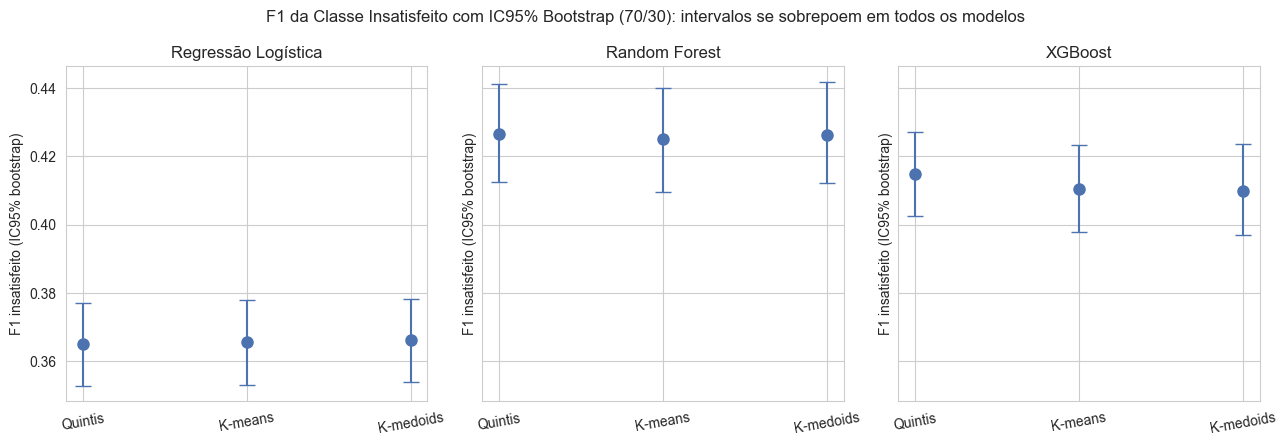

1o colocado nominal por combinacao (dentro do IC dos outros 2, em todos os casos):
  test_size=0.2 modelo=logreg: nominal 1o=quintil
  test_size=0.2 modelo=random_forest: nominal 1o=quintil
  test_size=0.2 modelo=xgboost: nominal 1o=kmedoids
  test_size=0.3 modelo=logreg: nominal 1o=kmedoids
  test_size=0.3 modelo=random_forest: nominal 1o=quintil
  test_size=0.3 modelo=xgboost: nominal 1o=quintil


In [28]:
nomes_modelo = {"logreg": "Regressão Logística", "random_forest": "Random Forest", "xgboost": "XGBoost"}

sub = resultados[resultados["test_size"] == MELHOR_SPLIT].copy()
sub["label"] = sub["segmentacao"].map({"quintil": "Quintis", "kmeans": "K-means", "kmedoids": "K-medoids"})

fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)
for ax, modelo in zip(axes, ["logreg", "random_forest", "xgboost"], strict=False):
    d = sub[sub["modelo"] == modelo].set_index("label").reindex(["Quintis", "K-means", "K-medoids"])
    yerr = np.array(
        [d["f1_insatisfeito"] - d["f1_insatisfeito_ci_lo"], d["f1_insatisfeito_ci_hi"] - d["f1_insatisfeito"]]
    )
    ax.errorbar(d.index, d["f1_insatisfeito"], yerr=yerr, fmt="o", capsize=6, color="#4C72B0", markersize=8)
    ax.set_title(nomes_modelo[modelo])
    ax.set_ylabel("F1 insatisfeito (IC95% bootstrap)")
    ax.tick_params(axis="x", rotation=10)

plt.suptitle(
    "F1 da Classe Insatisfeito com IC95% Bootstrap (70/30): intervalos se sobrepoem em todos os modelos", fontsize=12
)
plt.tight_layout()
plt.savefig(f"{ASSETS_FINAL}/bootstrap_ci_f1.png", dpi=150, bbox_inches="tight")
plt.show()

print("1o colocado nominal por combinacao (dentro do IC dos outros 2, em todos os casos):")
for ts in SPLIT_RATIOS:
    for modelo in ["logreg", "random_forest", "xgboost"]:
        d = resultados[(resultados["test_size"] == ts) & (resultados["modelo"] == modelo)]
        melhor = d.loc[d["f1_insatisfeito"].idxmax(), "segmentacao"]
        print(f"  test_size={ts} modelo={modelo}: nominal 1o={melhor}")

### 5.4 Refit dos Modelos (70/30, Segmentação K-means)

`resultados` guarda só métricas escalares e a matriz de confusão. Curvas PR/ROC completas e importância por feature (não só a agregada de "segmento") exigem as probabilidades e o pipeline treinado, refeitos aqui com a mesma configuração (mesmo `random_state`, mesmo split agrupado por cliente, resultado idêntico ao já reportado). Segmentação K-means usada como referência por ser o método mais elaborado tecnicamente (seção 3.1), não porque tenha desempenho preditivo melhor: a seção 5.1 mostrou que os 3 métodos não têm diferença defensável nessa métrica.


In [29]:
nomes_modelo = {"logreg": "Regressão Logística", "random_forest": "Random Forest", "xgboost": "XGBoost"}

categorical_cols_final = [*BASE_CATEGORICAL_COLS, "segmento"]
data_final = clf_base.rename(columns={"segmento_kmeans_k4": "segmento"})
x_all_final = data_final[NUMERIC_COLS + categorical_cols_final]
y_all_final = data_final["satisfacao"]
groups_final = data_final["customer_unique_id"]

gss_final = GroupShuffleSplit(n_splits=1, test_size=MELHOR_SPLIT, random_state=RANDOM_STATE)
tr_idx_f, te_idx_f = next(gss_final.split(x_all_final, y_all_final, groups=groups_final))
x_train_f, x_test_f = x_all_final.iloc[tr_idx_f], x_all_final.iloc[te_idx_f]
y_train_f, y_test_f = y_all_final.iloc[tr_idx_f], y_all_final.iloc[te_idx_f]

refit = {}
for model_name in ["logreg", "random_forest", "xgboost"]:
    scale = model_name == "logreg"
    pipe = Pipeline([("pre", build_preprocessor(categorical_cols_final, scale)), ("clf", make_model(model_name))])
    pred, proba_ord = fit_predict(pipe, model_name, x_train_f, y_train_f, x_test_f)
    refit[model_name] = {"pipe": pipe, "pred": pred, "proba": proba_ord, "y_test": y_test_f}
    f1_insat = f1_score(y_test_f, pred, labels=CLASSES_ORDER, average=None, zero_division=0)[0]
    print(f"{model_name}: refit OK, f1_insatisfeito={f1_insat:.4f}")

logreg: refit OK, f1_insatisfeito=0.3657


random_forest: refit OK, f1_insatisfeito=0.4251


xgboost: refit OK, f1_insatisfeito=0.4105


### 5.5 Classificação Binária (2 Classes), Comparável a SAHAJ (2021)

O F1 de 94% relatado por SAHAJ (2021) usa 2 classes (positiva: nota 4-5; negativa: nota 1-3), não 3 como o restante deste trabalho. Em vez de só registrar a ressalva de que os números não são comparáveis, replicamos o mesmo corte binário nos 3 métodos de segmentação (70/30, já decidido na seção 4.4, com o mesmo split agrupado por cliente), o que permite uma comparação mais direta com o artigo e testa se a ordem nominal entre os métodos de segmentação (seção 5.1: sem diferença defensável) se mantém quando a granularidade do alvo muda.


In [30]:
CLASSES_ORDER_BIN = ["negativa", "positiva"]
LABEL_ENCODER_BIN = LabelEncoder().fit(CLASSES_ORDER_BIN)


def classe_binaria(score):
    return "positiva" if score >= 4 else "negativa"


clf_base_bin = clf_base.copy()
clf_base_bin["satisfacao_bin"] = clf_base_bin["review_score"].apply(classe_binaria)


def make_model_bin(model_name):
    if model_name == "logreg":
        return LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
    if model_name == "random_forest":
        return RandomForestClassifier(n_estimators=150, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=4)
    return XGBClassifier(
        n_estimators=150, random_state=RANDOM_STATE, eval_metric="logloss", device=XGB_DEVICE, tree_method="hist"
    )


def fit_predict_bin(pipe, model_name, x_fit, y_fit, x_eval):
    if model_name == "xgboost":
        sw = compute_sample_weight("balanced", y_fit)
        y_fit_enc = LABEL_ENCODER_BIN.transform(y_fit)
        pipe.fit(x_fit, y_fit_enc, clf__sample_weight=sw)
        pred = LABEL_ENCODER_BIN.inverse_transform(pipe.predict(x_eval))
        proba, proba_classes = pipe.predict_proba(x_eval), list(LABEL_ENCODER_BIN.classes_)
    else:
        pipe.fit(x_fit, y_fit)
        pred = pipe.predict(x_eval)
        proba, proba_classes = pipe.predict_proba(x_eval), list(pipe.named_steps["clf"].classes_)
    col_idx = [proba_classes.index(c) for c in CLASSES_ORDER_BIN]
    return pred, proba[:, col_idx]


resultados_bin = []
for segment_key, segment_col_name in SEGMENT_METHODS.items():
    categorical_cols = [*BASE_CATEGORICAL_COLS, "segmento"]
    data = clf_base_bin.rename(columns={segment_col_name: "segmento"})
    x_all, y_all = data[NUMERIC_COLS + categorical_cols], data["satisfacao_bin"]
    groups_all = data["customer_unique_id"]
    gss = GroupShuffleSplit(n_splits=1, test_size=MELHOR_SPLIT, random_state=RANDOM_STATE)
    tr_idx, te_idx = next(gss.split(x_all, y_all, groups=groups_all))
    x_train, x_test = x_all.iloc[tr_idx], x_all.iloc[te_idx]
    y_train, y_test = y_all.iloc[tr_idx], y_all.iloc[te_idx]
    for model_name in ["logreg", "random_forest", "xgboost"]:
        scale = model_name == "logreg"
        pipe = Pipeline([("pre", build_preprocessor(categorical_cols, scale)), ("clf", make_model_bin(model_name))])
        pred, proba_ord = fit_predict_bin(pipe, model_name, x_train, y_train, x_test)
        f1c = f1_score(y_test, pred, labels=CLASSES_ORDER_BIN, average=None, zero_division=0)
        prec_curve, rec_curve, _ = precision_recall_curve((y_test == "negativa").astype(int), proba_ord[:, 0])
        resultados_bin.append(
            {
                "segmentacao": segment_key,
                "modelo": model_name,
                "f1_negativa": f1c[0],
                "f1_positiva": f1c[1],
                "f1_macro": f1c.mean(),
                "pr_auc_negativa": auc(rec_curve, prec_curve),
                "roc_auc": roc_auc_score((y_test == "positiva").astype(int), proba_ord[:, 1]),
                "accuracy": accuracy_score(y_test, pred),
            }
        )

resultados_bin_df = pd.DataFrame(resultados_bin)
print("Classificacao binaria (positiva/negativa, corte de SAHAJ 2021), 70/30:")
print(resultados_bin_df.round(4).to_string(index=False))

Classificacao binaria (positiva/negativa, corte de SAHAJ 2021), 70/30:
segmentacao        modelo  f1_negativa  f1_positiva  f1_macro  pr_auc_negativa  roc_auc  accuracy
    quintil        logreg       0.4212       0.7916    0.6064           0.4449   0.6811    0.6936
    quintil random_forest       0.3934       0.8778    0.6356           0.4621   0.6900    0.7966
    quintil       xgboost       0.4275       0.8225    0.6250           0.4750   0.6868    0.7290
     kmeans        logreg       0.4210       0.7907    0.6059           0.4447   0.6808    0.6926
     kmeans random_forest       0.3915       0.8769    0.6342           0.4594   0.6858    0.7952
     kmeans       xgboost       0.4280       0.8218    0.6249           0.4713   0.6876    0.7282
   kmedoids        logreg       0.4206       0.7902    0.6054           0.4447   0.6809    0.6920
   kmedoids random_forest       0.3927       0.8769    0.6348           0.4585   0.6859    0.7954
   kmedoids       xgboost       0.4243       0.

### 5.6 Modelo Preditivo Genuino (sem Vazamento Pos-Fato)

Os modelos ate aqui usam `atraso_dias` e `tempo_entrega`, que so existem depois da entrega, ou seja, depois de o pedido estar concluido e o cliente poder avaliar. Isso os torna **explicativos** (quais fatores se associam a satisfacao apos o fato), nao preditivos no sentido de um sistema em producao: no momento em que o pedido e feito, nenhum desses 2 valores existe ainda. Para medir quanto do desempenho depende de "ja saber que atrasou", a comparacao abaixo repete K-means/70/30 usando so features conhecidas no momento da compra (financeiras, de produto, geograficas e o segmento RFM).


In [31]:
# "segmento" fica de fora aqui, mesmo sendo teoricamente "conhecido antes da entrega": o
# rotulo vem de um clustering ajustado sobre o RFM de TODA a populacao (fit pos-fato, secao
# 3.1), e para os 96,9% de clientes de compra unica, "monetario" e o proprio valor do pedido
# sendo classificado. Incluir esse rotulo aqui misturaria o teste de vazamento pos-fato desta
# secao com o vazamento (mais fraco, indireto) do clustering. Mantido de fora para o teste
# medir so o efeito de atraso_dias/tempo_entrega, isoladamente.
NUMERIC_COLS_PRED = [
    "freight_value",
    "price",
    "payment_value",
    "payment_installments",
    "product_weight_g",
    "product_photos_qty",
    "product_description_lenght",
]
CATEGORICAL_COLS_PRED = [*BASE_CATEGORICAL_COLS]


def build_preprocessor_pred(scale_numeric):
    numeric_step = StandardScaler() if scale_numeric else "passthrough"
    return ColumnTransformer(
        [
            ("num", numeric_step, NUMERIC_COLS_PRED),
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL_COLS_PRED),
        ]
    )


x_all_pred = clf_base[NUMERIC_COLS_PRED + CATEGORICAL_COLS_PRED]
y_all_pred = clf_base["satisfacao"]
groups_pred = clf_base["customer_unique_id"]

gss_pred = GroupShuffleSplit(n_splits=1, test_size=MELHOR_SPLIT, random_state=RANDOM_STATE)
tr_idx_p, te_idx_p = next(gss_pred.split(x_all_pred, y_all_pred, groups=groups_pred))
x_train_p, x_test_p = x_all_pred.iloc[tr_idx_p], x_all_pred.iloc[te_idx_p]
y_train_p, y_test_p = y_all_pred.iloc[tr_idx_p], y_all_pred.iloc[te_idx_p]

resultados_pred = []
for model_name in ["logreg", "random_forest", "xgboost"]:
    scale = model_name == "logreg"
    pipe = Pipeline([("pre", build_preprocessor_pred(scale)), ("clf", make_model(model_name))])
    pred, proba_ord = fit_predict(pipe, model_name, x_train_p, y_train_p, x_test_p)
    f1c = f1_score(y_test_p, pred, labels=CLASSES_ORDER, average=None, zero_division=0)
    prec_curve, rec_curve, _ = precision_recall_curve((y_test_p == "insatisfeito").astype(int), proba_ord[:, 0])
    resultados_pred.append(
        {
            "modelo": model_name,
            "f1_insatisfeito": f1c[0],
            "f1_macro": f1c.mean(),
            "pr_auc_insatisfeito": auc(rec_curve, prec_curve),
            "accuracy": accuracy_score(y_test_p, pred),
        }
    )

resultados_pred_df = pd.DataFrame(resultados_pred)
print("Desempenho SEM atraso_dias/tempo_entrega (features conhecidas no momento da compra):")
print(resultados_pred_df.round(4).to_string(index=False))

comparacao_leakage = resultados[(resultados["segmentacao"] == "kmeans") & (resultados["test_size"] == MELHOR_SPLIT)][
    ["modelo", "f1_insatisfeito", "pr_auc_insatisfeito"]
].reset_index(drop=True)
comparacao_leakage.columns = ["modelo", "f1_com_atraso", "pr_auc_com_atraso"]
comparacao_final = comparacao_leakage.merge(
    resultados_pred_df[["modelo", "f1_insatisfeito", "pr_auc_insatisfeito"]], on="modelo"
).rename(columns={"f1_insatisfeito": "f1_sem_atraso", "pr_auc_insatisfeito": "pr_auc_sem_atraso"})
comparacao_final["queda_f1_pct"] = (1 - comparacao_final["f1_sem_atraso"] / comparacao_final["f1_com_atraso"]) * 100

print("\nComparacao: modelo explicativo (com atraso, pos-fato) vs preditivo genuino (sem atraso, pre-fato):")
print(comparacao_final.round(4).to_string(index=False))

Desempenho SEM atraso_dias/tempo_entrega (features conhecidas no momento da compra):
       modelo  f1_insatisfeito  f1_macro  pr_auc_insatisfeito  accuracy
       logreg           0.2531    0.3284               0.1801    0.4401
random_forest           0.1902    0.3652               0.1739    0.6999
      xgboost           0.2561    0.3510               0.1957    0.5046

Comparacao: modelo explicativo (com atraso, pos-fato) vs preditivo genuino (sem atraso, pre-fato):
       modelo  f1_com_atraso  pr_auc_com_atraso  f1_sem_atraso  pr_auc_sem_atraso  queda_f1_pct
       logreg         0.3657             0.3711         0.2531             0.1801       30.7814
random_forest         0.4251             0.4189         0.1902             0.1739       55.2573
      xgboost         0.4105             0.4283         0.2561             0.1957       37.6145


### 5.7 Matrizes de Confusão (70/30, Segmentação K-means)

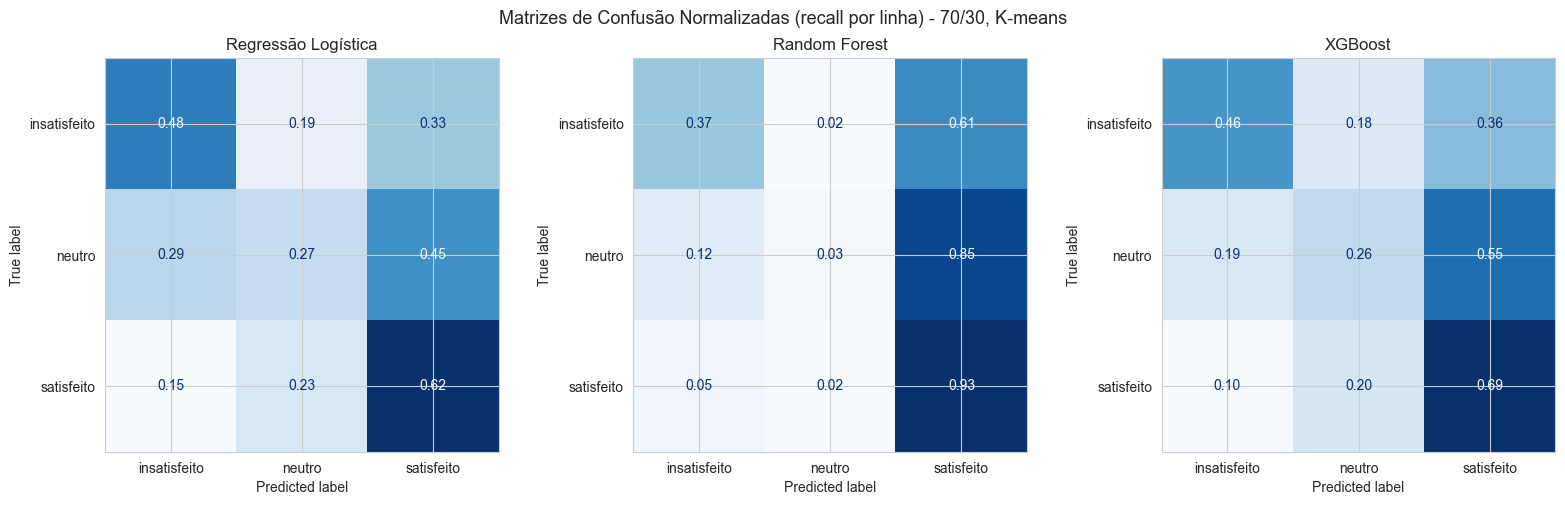

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, model_name in zip(axes, ["logreg", "random_forest", "xgboost"], strict=False):
    cm = confusion_matrix(
        refit[model_name]["y_test"], refit[model_name]["pred"], labels=CLASSES_ORDER, normalize="true"
    )
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES_ORDER)
    disp.plot(ax=ax, cmap="Blues", values_format=".2f", colorbar=False)
    ax.set_title(nomes_modelo[model_name])

plt.suptitle("Matrizes de Confusão Normalizadas (recall por linha) - 70/30, K-means", fontsize=13)
plt.tight_layout()
plt.savefig(f"{ASSETS_FINAL}/matrizes_confusao.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.8 Curvas PR e ROC (Classe Insatisfeito, one-vs-rest)

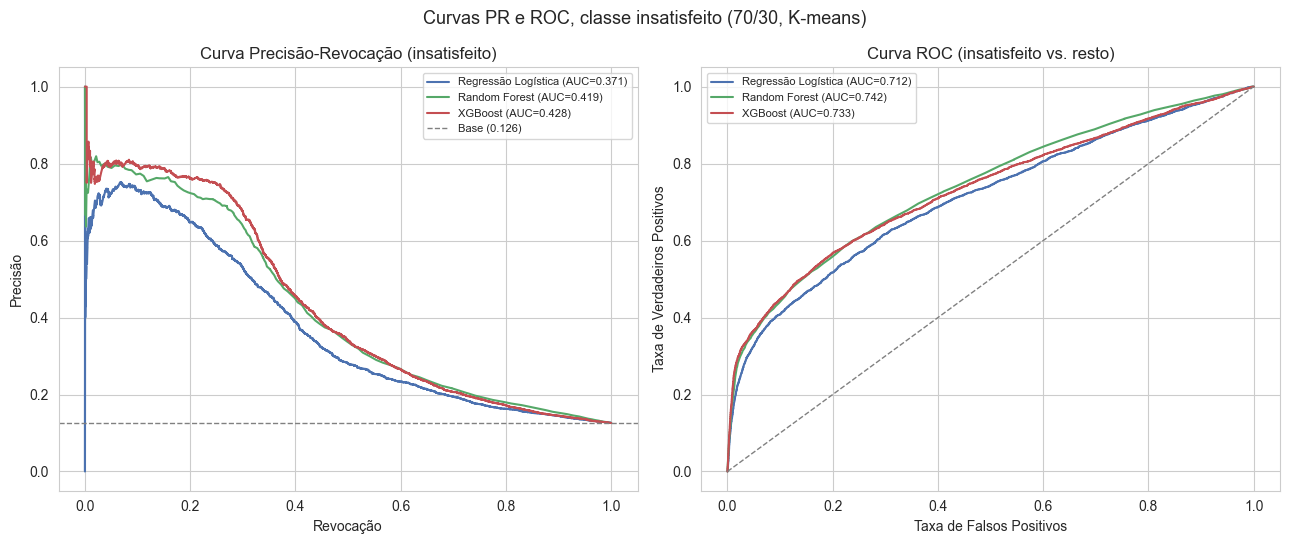

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
colors_model = {"logreg": "#4C72B0", "random_forest": "#55A868", "xgboost": "#C44E52"}

for model_name in ["logreg", "random_forest", "xgboost"]:
    y_true_bin = (refit[model_name]["y_test"] == "insatisfeito").astype(int)
    proba_insat = refit[model_name]["proba"][:, 0]

    prec, rec, _ = precision_recall_curve(y_true_bin, proba_insat)
    pr_auc_val = auc(rec, prec)
    axes[0].plot(rec, prec, label=f"{nomes_modelo[model_name]} (AUC={pr_auc_val:.3f})", color=colors_model[model_name])

    fpr, tpr, _ = roc_curve(y_true_bin, proba_insat)
    roc_auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, label=f"{nomes_modelo[model_name]} (AUC={roc_auc_val:.3f})", color=colors_model[model_name])

baseline_insat = y_true_bin.mean()
axes[0].axhline(baseline_insat, color="gray", linestyle="--", linewidth=1, label=f"Base ({baseline_insat:.3f})")
axes[0].set_xlabel("Revocação")
axes[0].set_ylabel("Precisão")
axes[0].set_title("Curva Precisão-Revocação (insatisfeito)")
axes[0].legend(fontsize=8)

axes[1].plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1)
axes[1].set_xlabel("Taxa de Falsos Positivos")
axes[1].set_ylabel("Taxa de Verdadeiros Positivos")
axes[1].set_title("Curva ROC (insatisfeito vs. resto)")
axes[1].legend(fontsize=8)

plt.suptitle("Curvas PR e ROC, classe insatisfeito (70/30, K-means)", fontsize=13)
plt.tight_layout()
plt.savefig(f"{ASSETS_FINAL}/curvas_pr_roc.png", dpi=150, bbox_inches="tight")
plt.show()

### 5.9 Importância das Features (Random Forest, 70/30, K-means)

Colunas one-hot da mesma variável original (ex.: `product_category_name_english_*`) são somadas de volta à variável de origem, para leitura direta por feature de negócio.

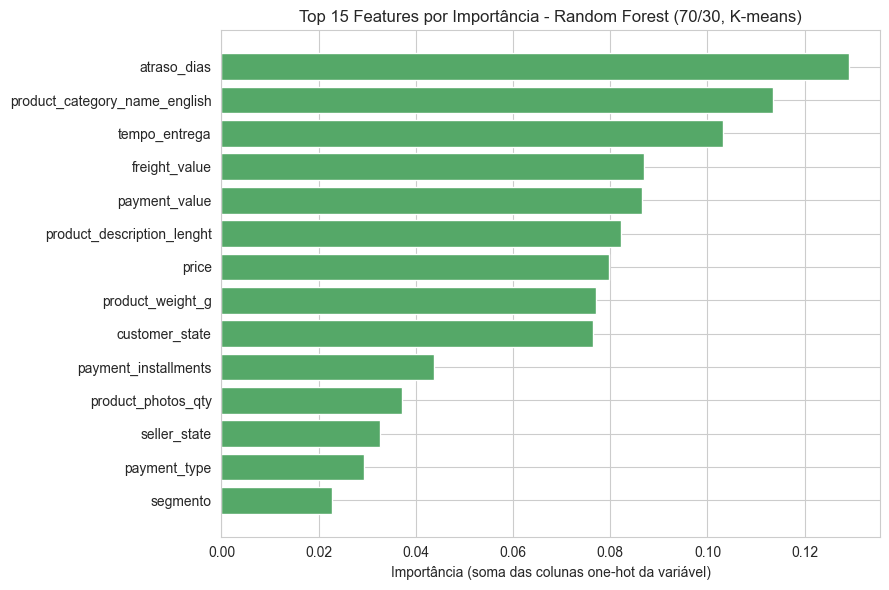

origem
atraso_dias                      0.1291
product_category_name_english    0.1135
tempo_entrega                    0.1031
freight_value                    0.0870
payment_value                    0.0865
product_description_lenght       0.0822
price                            0.0797
product_weight_g                 0.0771
customer_state                   0.0765
payment_installments             0.0438
product_photos_qty               0.0371
seller_state                     0.0326
payment_type                     0.0292
segmento                         0.0227
Name: importancia, dtype: float64


In [34]:
rf_pipe = refit["random_forest"]["pipe"]
feature_names_rf = rf_pipe.named_steps["pre"].get_feature_names_out()
importances_rf = rf_pipe.named_steps["clf"].feature_importances_

feat_imp = pd.DataFrame({"feature": feature_names_rf, "importancia": importances_rf})


def origem(nome):
    nome = nome.replace("num__", "").replace("cat__", "")
    for col in [*NUMERIC_COLS, *categorical_cols_final]:
        if nome == col or nome.startswith(f"{col}_"):
            return col
    return nome


feat_imp["origem"] = feat_imp["feature"].apply(origem)
top_features = feat_imp.groupby("origem")["importancia"].sum().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_features.index[::-1], top_features.values[::-1], color="#55A868")
ax.set_xlabel("Importância (soma das colunas one-hot da variável)")
ax.set_title("Top 15 Features por Importância - Random Forest (70/30, K-means)")
plt.tight_layout()
plt.savefig(f"{ASSETS_FINAL}/importancia_features.png", dpi=150, bbox_inches="tight")
plt.show()

print(top_features.round(4))

### 5.10 Permutation Importance: Corrigindo o Vies da Importancia por Impureza

O ranking anterior soma a importancia por impureza (Gini) das colunas one-hot de volta a variavel original. Essa metrica e sabidamente enviesada a favor de variaveis de alta cardinalidade (`product_category_name_english` tem 71 niveis, `customer_state` tem 27): mais colunas dao mais chances de reducao de impureza, inflando o total somado mesmo sem ganho real de sinal. A permutation importance mede o efeito direto: embaralha uma variavel original por vez e observa a queda no F1 macro do modelo ja treinado, sem o vies de contagem de colunas.


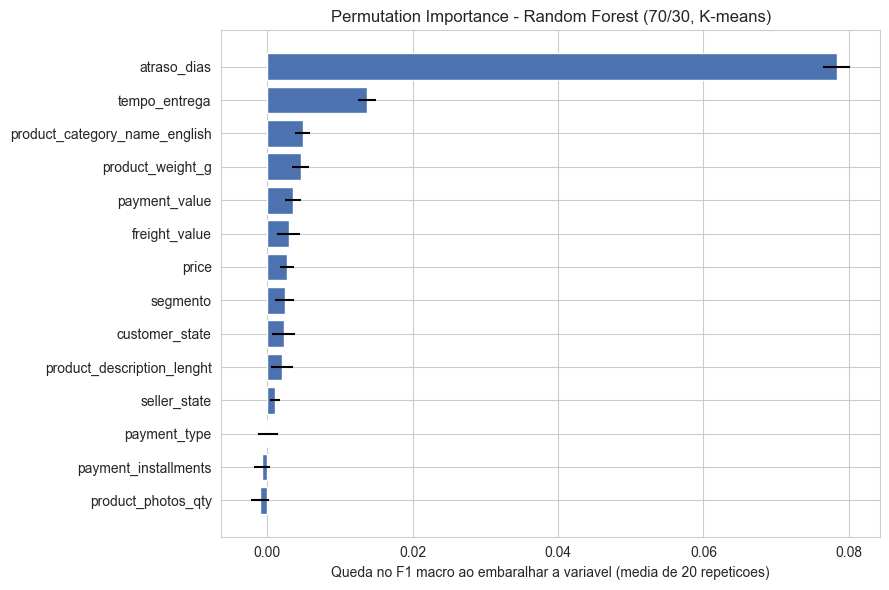

atraso_dias                      0.0783
tempo_entrega                    0.0137
product_category_name_english    0.0049
product_weight_g                 0.0046
payment_value                    0.0035
freight_value                    0.0030
price                            0.0027
segmento                         0.0024
customer_state                   0.0023
product_description_lenght       0.0020
seller_state                     0.0011
payment_type                     0.0001
payment_installments            -0.0007
product_photos_qty              -0.0009
dtype: float64

Desvio padrao (n_repeats=20):
atraso_dias                      0.0019
tempo_entrega                    0.0013
product_category_name_english    0.0010
product_weight_g                 0.0011
payment_value                    0.0011
freight_value                    0.0016
price                            0.0010
segmento                         0.0013
customer_state                   0.0016
product_description_lenght       0

In [35]:
# 20 repeticoes, nao 5: o desvio padrao entre repeticoes com 5 era da mesma ordem de grandeza
# da propria importancia, insuficiente para comparar posicoes adjacentes do ranking com
# confianca. Com 20, o desvio cai para 0,001-0,002.
perm_result = permutation_importance(
    rf_pipe,
    x_test_f,
    y_test_f,
    n_repeats=20,
    random_state=RANDOM_STATE,
    n_jobs=4,
    scoring="f1_macro",
)
perm_imp = pd.Series(perm_result.importances_mean, index=x_test_f.columns).sort_values(ascending=False)
perm_std = pd.Series(perm_result.importances_std, index=x_test_f.columns).reindex(perm_imp.index)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(perm_imp.index[::-1], perm_imp.values[::-1], xerr=perm_std.values[::-1], color="#4C72B0")
ax.set_xlabel("Queda no F1 macro ao embaralhar a variavel (media de 20 repeticoes)")
ax.set_title("Permutation Importance - Random Forest (70/30, K-means)")
plt.tight_layout()
plt.savefig(f"{ASSETS_FINAL}/permutation_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print(perm_imp.round(4))
print("\nDesvio padrao (n_repeats=20):")
print(perm_std.round(4))

comp_imp = pd.DataFrame(
    {
        "impureza_rank": top_features.rank(ascending=False).astype(int),
        "permutacao_rank": perm_imp.reindex(top_features.index).rank(ascending=False).astype(int),
    }
).sort_values("impureza_rank")
print("\nComparacao de ranking: impureza (viesada por cardinalidade) vs permutacao:")
print(comp_imp)

### 5.11 Importância da Feature "Segmento" entre os 3 Métodos de Segmentação

Compara, dentro de cada modelo, o quanto a feature "segmento" pesa quando ela vem de quintis, K-means ou K-medoids (proporção 70/30, decidida na seção 5.3). Responde ao motivo de rodar a classificação 3 vezes (seção 4): entender o efeito de cada método de segmentação, não só comparar os métodos isoladamente.

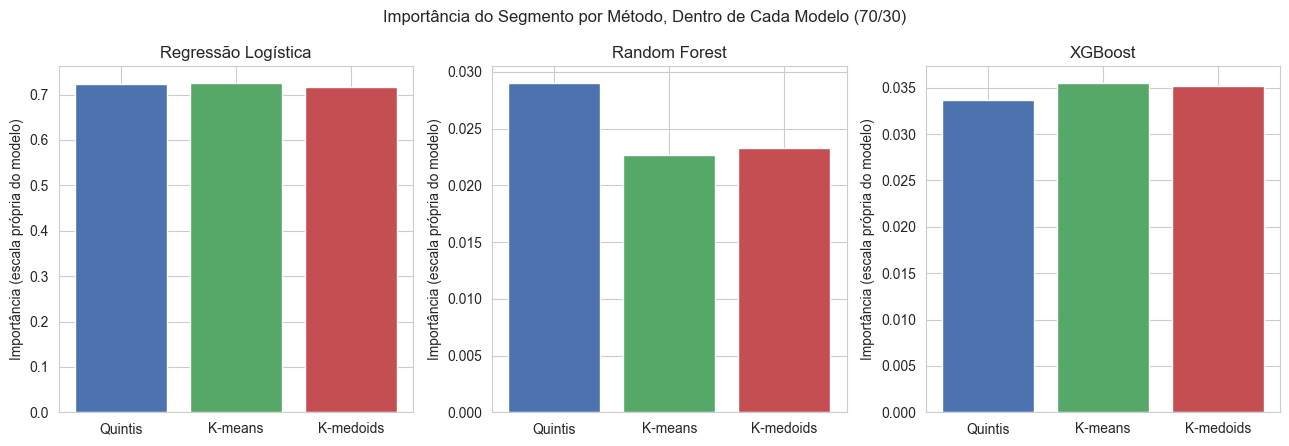

segmentacao    quintil  kmeans  kmedoids
modelo                                  
logreg          0.7232  0.7257    0.7165
random_forest   0.0290  0.0227    0.0233
xgboost         0.0336  0.0355    0.0352


In [36]:
imp_seg_70_30 = resultados[resultados["test_size"] == MELHOR_SPLIT].pivot(
    index="modelo", columns="segmentacao", values="importancia_segmento"
)[["quintil", "kmeans", "kmedoids"]]

# 3 subplots com eixo Y proprio cada, em vez de 1 grafico so: a escala da Regressao Logistica
# (soma de |coeficientes|, ~0.7-0.9) nao e comparavel a de RF/XGBoost (fracao de impureza,
# ~0.03), como o texto ja observa. Colocar as 3 na mesma barra esmagaria visualmente RF/XGBoost
# e sugeriria uma comparacao entre modelos que a analise explicitamente rejeita.
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5))
cores = ["#4C72B0", "#55A868", "#C44E52"]
for ax, modelo in zip(axes, ["logreg", "random_forest", "xgboost"], strict=False):
    valores = imp_seg_70_30.loc[modelo]
    ax.bar(["Quintis", "K-means", "K-medoids"], valores.values, color=cores)
    ax.set_title(nomes_modelo[modelo])
    ax.set_ylabel("Importância (escala própria do modelo)")

plt.suptitle("Importância do Segmento por Método, Dentro de Cada Modelo (70/30)", fontsize=12)
plt.tight_layout()
plt.savefig(f"{ASSETS_FINAL}/importancia_segmento_metodos.png", dpi=150, bbox_inches="tight")
plt.show()

print(imp_seg_70_30.round(4))